# 라이브러리 설치

In [1]:
# 기본 유틸
import os
import sys
import time
import gc
import warnings
import pickle
import json
import re
import random
import tempfile
import zlib
import olefile
import shutil
import subprocess
import uuid
from datetime import datetime
from dotenv import load_dotenv
from getpass import getpass
from collections import Counter
from typing import List, Dict, Any
from difflib import SequenceMatcher

# PyTorch
import torch

# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import koreanize_matplotlib
import plotly.express as px
from wordcloud import WordCloud
from PIL import Image

# 머신러닝 / 차원축소
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import Levenshtein

# PDF / HTML 처리
from pypdf import PdfReader, PdfWriter, errors
from bs4 import BeautifulSoup
import html2text

# SentenceTransformers
from sentence_transformers import CrossEncoder, SentenceTransformer

# 한국어 형태소 분석
from kiwipiepy import Kiwi

# LangChain Core
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.documents import Document

# LangChain Community & Classic
from langchain_community.retrievers import BM25Retriever
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_classic.retrievers.ensemble import EnsembleRetriever

# LangChain Text Splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker

# Upstage
from langchain_upstage import UpstageDocumentParseLoader, UpstageEmbeddings, ChatUpstage

# HuggingFace / Transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline

# Vector DB (Qdrant)
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore

# Jupyter Display
from IPython.display import display, Markdown, HTML

# Progress Bar
from tqdm import tqdm

# Windows COM (필요 시)
import win32com.client
import pythoncom

# 경고 무시
warnings.filterwarnings("ignore")

# 환경변수 로드
load_dotenv()

print("모든 라이브러리 정상 로드 완료")
print(f"PyTorch CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

모든 라이브러리 정상 로드 완료
PyTorch CUDA 사용 가능: True
   GPU: NVIDIA GeForce RTX 5070


In [3]:
# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# EDA

## 메타데이터 탐색

### CSV 데이터 로드

In [4]:
# 경로 설정 (사용자 환경에 맞게 수정)
BASE_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트"
CSV_PATH = os.path.join(BASE_PATH, "data_list.csv")
FILES_DIR = os.path.join(BASE_PATH, "files")

# CSV 파일 열기 (인코딩 문제 방지용 처리 포함)
def load_metadata(path):
    try:
        # 윈도우 엑셀 저장본일 경우 보통 cp949
        df = pd.read_csv(path, encoding='cp949')
        print("인코딩: CP949로 성공적으로 열었음")
    except UnicodeDecodeError:
        try:
            # 일반적인 경우 utf-8
            df = pd.read_csv(path, encoding='utf-8')
            print("인코딩: UTF-8로 성공적으로 열었음")
        except Exception as e:
            print(f"파일 열기 실패: {e}")
            return None
    return df

# 실제 폴더 내 파일명 긁어오기
if os.path.exists(FILES_DIR):
    real_files = os.listdir(FILES_DIR)
    print(f"'files' 폴더 안에 총 {len(real_files)}개의 파일이 존재함\n")
    
    print("실제 파일명 미리보기 (상위 3개)")
    for i, fname in enumerate(real_files[:3]):
        print(f"{i+1}. {fname}")
else:
    print("경로 에러: 지정하신 경로에 폴더가 없음 경로를 확인해야됨")
    real_files = []

# 실행 및 데이터 확인
df = load_metadata(CSV_PATH)

if df is not None:
    print("\n[데이터 정보 요약]")
    print(df.info(3))  # 컬럼명과 데이터 타입 확인

'files' 폴더 안에 총 100개의 파일이 존재함

실제 파일명 미리보기 (상위 3개)
1. (사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp
2. (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp
3. (사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp
인코딩: UTF-8로 성공적으로 열었음

[데이터 정보 요약]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   공고 번호      82 non-null     object 
 1   공고 차수      82 non-null     float64
 2   사업명        100 non-null    object 
 3   사업 금액      99 non-null     float64
 4   발주 기관      100 non-null    object 
 5   공개 일자      100 non-null    object 
 6   입찰 참여 시작일  74 non-null     object 
 7   입찰 참여 마감일  92 non-null     object 
 8   사업 요약      100 non-null    object 
 9   파일형식       100 non-null    object 
 10  파일명        100 non-null    object 
 11  텍스트        100 non-null    object 
dtypes: float64(2), object(10)
memory usage: 9.5+ KB
None


- 일단 로드때부터 결측치들이 있음을 확인
- 뒤에서 더 자세히 알아볼 것

### 무결성 검증(CSV 데이터 vs 실제 파일 시스템 검증)

In [5]:
# ==============================================================================
# 파일 무결성 및 정합성 검증
# ==============================================================================
import binascii

# 함수 정의
def detect_file_type(filepath):
    # 파일의 매직 넘버를 확인하여 실제 파일 형식을 반환
    if not os.path.exists(filepath):
        return "파일없음"
    
    try:
        with open(filepath, 'rb') as f:
            header = f.read(8)
            hex_header = binascii.hexlify(header).upper()
            
            if hex_header.startswith(b'D0CF11E0'):
                return "Original_HWP"
            elif hex_header.startswith(b'504B0304'):
                return "HWPX_or_ZIP"
            elif hex_header.startswith(b'25504446'):
                return "PDF"
            else:
                return f"Other ({hex_header.decode('ascii')})"
    except:
        return "Read_Error"


def analyze_corruption(filepath):
    # 파일 손상 여부를 상세 분석
    if not os.path.exists(filepath):
        return None
    
    try:
        with open(filepath, 'rb') as f:
            header_bytes = f.read(16)
            header_hex = binascii.hexlify(header_bytes).upper().decode('ascii')
            formatted_hex = ' '.join([header_hex[i:i+2] for i in range(0, len(header_hex), 2)])
            
            is_corrupted = b'\xEF\xBF\xBD' in header_bytes
            
            return {
                'hex': formatted_hex,
                'is_corrupted': is_corrupted
            }
    except:
        return None


# 검증 시작
print("\n" + "=" * 100)
print("파일 무결성 및 정합성 검증")
print("=" * 100)

# CSV vs 파일 시스템 집합 준비
real_files_set = set(real_files)
csv_files_set = set(df['파일명'].unique())

# [1] 기본 정보
print("\n[1] 기본 정보")
print("-" * 100)
print(f"CSV에 등록된 파일 수: {len(df)}개")
print(f"실제 폴더의 파일 수: {len(real_files)}개")
print(f"일치 여부: {'일치' if len(df) == len(real_files) else '불일치'}")

# [2] CSV vs 파일 시스템 정합성
print("\n[2] CSV vs 파일 시스템 정합성")
print("-" * 100)

missing_files = csv_files_set - real_files_set
print(f"CSV 명단에는 있는데 실제 폴더에 없는 파일: {len(missing_files)}개")
if len(missing_files) > 0:
    print(f"  예시: {list(missing_files)[:5]}")

ghost_files = real_files_set - csv_files_set
print(f"폴더에는 있는데 CSV 명단에 없는 파일: {len(ghost_files)}개")
if len(ghost_files) > 0:
    print(f"  예시: {list(ghost_files)[:5]}")

# [3] 확장자 분포
print("\n[3] 확장자 분포")
print("-" * 100)
hwp_count = sum(1 for f in real_files if f.lower().endswith('.hwp') or f.lower().endswith('.hwpx'))
pdf_count = sum(1 for f in real_files if f.lower().endswith('.pdf'))
other_count = len(real_files) - hwp_count - pdf_count

print(f"HWP/HWPX 파일: {hwp_count}개")
print(f"PDF 파일: {pdf_count}개")
print(f"기타 파일: {other_count}개")

# [4] 파일 포맷 검증 (매직 넘버)
print("\n[4] 파일 포맷 검증")
print("-" * 100)

format_mismatch = []

for idx, row in df.iterrows():
    filename = str(row['파일명'])
    ext = os.path.splitext(filename)[1].lower()
    full_path = os.path.join(FILES_DIR, filename)
    
    real_type = detect_file_type(full_path)
    
    if ext == '.hwp' and real_type != "Original_HWP":
        format_mismatch.append({
            'idx': idx,
            'filename': filename,
            'ext': ext,
            'real_type': real_type,
            'path': full_path
        })

if not format_mismatch:
    print("모든 파일의 확장자와 실제 포맷이 일치")
else:
    print(f"확장자와 실제 포맷이 불일치하는 파일: {len(format_mismatch)}개\n")
    print(f"{'인덱스':<8} {'파일명':<50} {'확장자':<10} {'실제 형식':<20}")
    print("-" * 100)
    
    for item in format_mismatch:
        print(f"{item['idx']:<8} {item['filename'][:45]:<50} {item['ext']:<10} {item['real_type']:<20}")

# [5] 손상 파일 정밀 진단
if format_mismatch:
    print("\n[5] 손상 파일 정밀 진단")
    print("-" * 100)
    
    for item in format_mismatch:
        print(f"\n파일명: {item['filename']}")
        print("-" * 100)
        
        result = analyze_corruption(item['path'])
        
        if result:
            print(f"헤더 데이터(Hex): {result['hex']}")
            print(f"정상 HWP 헤더:    D0 CF 11 E0 A1 B1 1A E1 ...")
            
            if result['is_corrupted']:
                print("\n[손상 확인] UTF-8 인코딩 과정에서 바이너리 손상 감지")
                print("  - EF BF BD 패턴 발견 (Replacement Character)")
                print("  - 원본 바이너리 데이터가 손실됨")
                print("  - 복구 불가능: 원본 파일 재다운로드 필요")
            else:
                print("\n[분석] 손상 패턴이 특이함. 다른 원인 가능성 있음")
        else:
            print("파일 읽기 실패")

# [6] CSV 데이터 샘플 (상위 3개) CSV가 어떻게 생겼나
print("\n[6] CSV 데이터 샘플 (상위 3개)")
print("-" * 100)
display(df.head(3))

# [7] 원본 파일 내용 샘플 (상위 3개) 원본 파일이 어떻게 생겼나 제대로 열리나
print("\n[7] 원본 파일 내용 샘플 (상위 3개)")
print("-" * 100)

def get_file_content_sample(filepath, max_chars=200):
    # 파일에서 텍스트 샘플 추출
    try:
        if filepath.lower().endswith('.hwp'):
            f = olefile.OleFileIO(filepath)
            if ["PrvText"] in f.listdir():
                text = f.openstream("PrvText").read().decode("utf-16le", errors='ignore')
                return text[:max_chars]
            return "텍스트 추출 실패 (PrvText 없음)"
        
        elif filepath.lower().endswith('.pdf'):
            from pypdf import PdfReader
            reader = PdfReader(filepath)
            if len(reader.pages) > 0:
                text = reader.pages[0].extract_text()
                return text[:max_chars]
            return "텍스트 추출 실패 (페이지 없음)"
        
        else:
            return "지원하지 않는 파일 형식"
    
    except Exception as e:
        return f"읽기 실패: {str(e)[:50]}"

for i, file in enumerate(real_files[:3]):
    file_path = os.path.join(FILES_DIR, file)
    print(f"{i+1}. {file}")
    print(f"   크기: {os.path.getsize(file_path):,} bytes")
    print("-" * 100)
    print(get_file_content_sample(file_path))
    print()

print("=" * 100)
print("검증 완료")
print("=" * 100)


파일 무결성 및 정합성 검증

[1] 기본 정보
----------------------------------------------------------------------------------------------------
CSV에 등록된 파일 수: 100개
실제 폴더의 파일 수: 100개
일치 여부: 일치

[2] CSV vs 파일 시스템 정합성
----------------------------------------------------------------------------------------------------
CSV 명단에는 있는데 실제 폴더에 없는 파일: 0개
폴더에는 있는데 CSV 명단에 없는 파일: 0개

[3] 확장자 분포
----------------------------------------------------------------------------------------------------
HWP/HWPX 파일: 96개
PDF 파일: 4개
기타 파일: 0개

[4] 파일 포맷 검증
----------------------------------------------------------------------------------------------------
확장자와 실제 포맷이 불일치하는 파일: 1개

인덱스      파일명                                                확장자        실제 형식               
----------------------------------------------------------------------------------------------------
25       한국농어촌공사_아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아.hw      .hwp       Other (EFBFBDEFBFBD11E0)

[5] 손상 파일 정밀 진단
--------------------------------------------

,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...



[7] 원본 파일 내용 샘플 (상위 3개)
----------------------------------------------------------------------------------------------------
1. (사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp
   크기: 4,262,912 bytes
----------------------------------------------------------------------------------------------------


<><>
<2024년 ｢벤처확인종합관리시스템 기능 고도화｣ 용역사업 (복수의결권주식, 스톡옵션, 성과조건부주식) - 제안요청서>
<><>

2024. 03.


<><<><><><><목  차><><><><>><>
<><>
< 1. 추진개요  3      2. 추진방안  5      3. 추진내용  9      4. 제안요청내용  24

2. (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp
   크기: 286,208 bytes
----------------------------------------------------------------------------------------------------


< 제 안 요 청 서 BIFF&ACFM 온라인서비스 재개발 및 행사지원시스템 공급 용역 >

2024. 6.
<><>  
<목차>
<>
<Ⅰ. 사업안내><>
<><사업개요><><3><>
<><사업목표><><3><>
<><사업유형><><4><>
<><4. 사업추진계획><><5><>
<>
<Ⅱ. 과업안내><>
<><과업의 범위><

3. (사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp
   크기: 902,144 bytes
--------------------------------------------------------------------------------

- 분석
    - 제공받은 data_list.csv 메타데이터와 실제 files 디렉토리 내 물리적 파일 100건에 대한 전수 조사를 수행함 파일 수량은 완벽히 일치하나 바이너리 레벨에서의 파일 손상이 1건 발견되어 이에 대한 조치가 필요함 또한 HWP 포맷이 96%를 차지하고 있어 전처리 파이프라인의 표준화가 시급함
        - 바이너리 파일이 텍스트(UTF-8)로 잘못 읽히거나 저장되는 과정에서 깨짐 발생 EF BF BD는 유니코드의 (Replacement Character)에 해당함 
        - 손상된 파일은 나라장터에서 원본 파일을 다시 다운로드함
        - 압도적인 HWP 비중을 보임 Python 환경(Linux 기반 서버 등)에서 HWP 텍스트 추출은 olefile이나 pyhwp 라이브러리로 가능하지만 표(Table) 파싱이나 레이아웃 보존에 한계가 있음 범용성과 호환성도 압도적이고 텍스트 추출 정확도, 처리 속도 등을 고려했을 때 PDF로 통일하기로 함
        - HWP를 PDF로 변환할 때 '텍스트 레이어'가 살아있는지 확인해야 함 이미지로만 변환되면 OCR 비용이 추가로 발생함

### CSV 데이터 오염 검사

In [6]:
# ==============================================================================
# 1. 노이즈 사전 정의
# ==============================================================================
GARBAGE_STRINGS = [
    "해당없음", "해당사항없음", "없음", "무", "미정", "미공개", "알수없음", "정보없음", 
    "미기입", "미등록", "미상", "미확인", "비공개", "비밀", "공개금지", "협의", "협의후",
    "nan", "null", "none", "n/a", "na", "nil", "undefined", "unknown", "tbd", "todo",
    "-", "--", ".", "..", "?", "??", "*"
]

POLLUTION_PATTERNS = [
    (re.compile(r'^(.)\1{4,}$'), "동일 문자 5회 이상 반복"),
    (re.compile(r'^[^\w가-힣\s]+$'), "순수 기호만 존재"),
    (re.compile(r'^<[^>]+>$'), "HTML 태그 잔재"),
    (re.compile(r'^(http|https|www)\S+'), "URL 링크만 존재"),
]

# ==============================================================================
# 2. 정밀 진단 로직
# ==============================================================================
def detect_pollution_full(df):
    pollution_report = []
    
    # 임시 컬럼 제외하고 원본 컬럼만 선택
    target_cols = [c for c in df.columns if not c.endswith('_dt') and c not in ['text_norm', 'summary_norm', 'calc_days']]
    
    # 컬럼별 타입 자동 추론
    col_types = {}
    for col in target_cols:
        if col in ['공고 번호']: col_types[col] = 'id'
        elif col in ['사업 금액']: col_types[col] = 'currency'
        elif col in ['공개 일자', '입찰 참여 시작일', '입찰 참여 마감일']: col_types[col] = 'date'
        elif col in ['공고 차수']: col_types[col] = 'numeric'
        else: col_types[col] = 'text'

    # 사업금액 소수점(.0) 카운팅용 변수 (로직은 유지하되 출력만 안 함)
    dot_zero_pass_count = 0

    # 전체 데이터 순회
    for col in target_cols:
        print(f"스캔 중", end="\r")
        col_type = col_types.get(col, 'text')
        
        for idx, val in df[col].items():
            issues = []
            
            # 1) 물리적 결측 (NaN/NaT)
            if pd.isna(val):
                issues.append(("물리적 결측(NaN)", "값이 비어있음"))
            
            else:
                str_val = str(val).strip()
                str_val_lower = str_val.lower()
                
                # 2) 의미적 결측
                if str_val_lower in GARBAGE_STRINGS:
                    issues.append(("의미적 결측(Garbage)", f"의미 없는 값: '{val}'"))
                
                # 3) 투명 인간 (공백만 존재)
                elif len(str_val) == 0:
                    issues.append(("유령 데이터", "눈에 안 보이는 공백만 존재"))
                
                # 4) 정규식 패턴 오염
                for pattern, desc in POLLUTION_PATTERNS:
                    if pattern.match(str_val):
                        issues.append(("패턴 오염", f"{desc}: '{val}'"))
                
                # 5) 컬럼 타입별 특수 검사
                if col_type == 'currency':
                    # 소수점(.0) 제거 후 검사
                    clean_val = str_val.replace('.0', '')
                    
                    # 만약 .0을 지웠더니 달라졌으면 -> 소수점 데이터였음 (카운팅만 하고 패스)
                    if str_val != clean_val:
                        dot_zero_pass_count += 1
                    
                    # 숫자, 콤마, 원, 공백을 제외한 이상한 문자가 있는지 확인
                    if re.search(r'[^\d,원\s]', clean_val):
                        issues.append(("형식 불일치", f"금액에 이상한 문자 혼입: '{val}'"))
                        
                elif col_type == 'id':
                    if re.search(r'[^\w\-\.]', str_val):
                        issues.append(("ID 형식 오류", f"ID에 특수문자 포함: '{val}'"))

            # 리포트에 기록 (출력을 위해 사업명, 파일명 정보 추가)
            if issues:
                for issue_type, issue_msg in issues:
                    pollution_report.append({
                        'Column': col,
                        'Index': idx,
                        'Type': issue_type,
                        'Value': f"'{val}'",
                        'Message': issue_msg,
                        # [수정] 상세 출력을 위해 정보 추가
                        'project_name': df.at[idx, '사업명'] if '사업명' in df.columns else 'N/A',
                        'filename': df.at[idx, '파일명'] if '파일명' in df.columns else 'N/A'
                    })
    
    return pollution_report, target_cols, dot_zero_pass_count

# 3. 리포트 출력
def generate_final_report(pollution_report, checked_cols, dot_zero_count):
    
    report_df = pd.DataFrame(pollution_report)
    
    # 1) 문제가 발견된 컬럼 출력
    print("\n\n[컬럼별 오염 현황 - 문제가 있는 곳]")
    if not pollution_report:
        print("   발견된 문제가 없음")
    else:
        for col in report_df['Column'].unique():
            col_issues = report_df[report_df['Column'] == col]
            print(f"\n   [{col}] (오염 {len(col_issues)}건)")
            print("-" * 80)
            
            # 상세 내역 반복 출력
            for _, row in col_issues.iterrows():
                print(f"    ▶ [Index {row['Index']}] {row['project_name']}")
                print(f"       오류 유형: {row['Type']}")
                print(f"       오류 내용: {row['Message']}")
                print(f"       파일명: {row['filename']}")
                print("-" * 40)

    # 2) 문제가 없는 컬럼 출력
    print("\n" + "-"*80)
    print("[검사 통과 - 깨끗한 컬럼]")
    problematic_cols = report_df['Column'].unique() if not report_df.empty else []
    clean_cols = [c for c in checked_cols if c not in problematic_cols]
    
    if clean_cols:
        print(f"   나머지 {len(clean_cols)}개 컬럼은 오염물질이 발견되지 않음")
        print(f"   목록: {', '.join(clean_cols)}")
    else:
        print("   모든 컬럼에서 하나 이상의 문제가 발견됨")

# 실행
pollution_report, checked_cols, dot_zero_count = detect_pollution_full(df)
generate_final_report(pollution_report, checked_cols, dot_zero_count)
print("="*80)

스캔 중

[컬럼별 오염 현황 - 문제가 있는 곳]

   [공고 번호] (오염 18건)
--------------------------------------------------------------------------------
    ▶ [Index 7] 차세대 포털·학사 정보시스템 구축사업 
       오류 유형: 물리적 결측(NaN)
       오류 내용: 값이 비어있음
       파일명: 고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
----------------------------------------
    ▶ [Index 12] [사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역
       오류 유형: 물리적 결측(NaN)
       오류 내용: 값이 비어있음
       파일명: 서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf
----------------------------------------
    ▶ [Index 13] [입찰공고] 산학협력단 정보시스템 운영 용역업체 선정
       오류 유형: 물리적 결측(NaN)
       오류 내용: 값이 비어있음
       파일명: 경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp
----------------------------------------
    ▶ [Index 14] 건설통합시스템(CMS) 고도화
       오류 유형: 물리적 결측(NaN)
       오류 내용: 값이 비어있음
       파일명: 한국수자원공사_건설통합시스템(CMS) 고도화.hwp
----------------------------------------
    ▶ [Index 15] 통합정보시스템 고도화 용역
       오류 유형: 물리적 결측(NaN)
       오류 내용: 값이 비어있음
       파일명: 국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp
-----------------------

- 분석
    - 데이터의 물리적 무결성(Phase 1)은 확보되었으나 메타데이터(CSV) 필드 값의 유효성 검사 결과 다수의 결측(Missing Value)과 정보 불일치가 발견됨 특히 RAG 시스템의 핵심 키(Key)가 되는 공고 번호의 누락과 검색 필터링에 필수적인 일정/금액 정보의 부재는 검색 품질에 치명적임 이를 해결하기 위해 수작업 보정 및 외부 데이터(입찰공고문) 추가 확보를 결정
    - 2.1. 식별자(Identity) 데이터 오염
        - RAG 시스템에서 문서를 고유하게 식별하고 API를 호출할 때 사용하는 Key 값이 누락된 치명적 오류이다 Vector DB에 저장 시 문서 ID 생성이 불가할 것이다
        - 공고 번호 및 공고 차수 컬럼에서 동일한 18건의 결측(NaN) 발견
        - 나라장터 API 수집 과정에서의 누락 혹은 원본 데이터 작성 시점의 오류로 추정
        - 엔지니어링 팀원(김모건) 수작업 전수 조사를 통해 18건의 공고 번호 및 차수 매핑 완료
    - 2.2. 일정(Timeline) 데이터 오염
        - 입찰 참여 시작일: 26건 결측
        - 입찰 참여 마감일: 8건 결측
        - RFP(제안요청서) 파일 내에는 "입찰 공고서 참조"라고만 적혀 있고 구체적인 날짜가 명시되지 않은 경우가 다수 또는 아예 언급 자체가 없음
        - "다음 주 마감인 사업 찾아줘"와 같은 기간 기반 필터링(Time-Filtering) 쿼리 처리 불가능
    - 2.3. 예산(Budget) 데이터 오염 및 불일치
        - CSV 상의 데이터와 실제 파일 내용이 다르거나, 둘 다 정보가 없는 경우가 혼재되어 있음
            - (물리적 결측): [Index 59] 기업 재생에너지 지원센터... 건은 CSV에 금액이 없음 (NaN) 확인 결과 원본 HWP 파일 내부에는 금액 정보가 존재함
            - (정보 불일치): CSV에는 금액이 있으나 파일에는 없는 경우(예: 국방과학연구소, 기초과학연구원 관련 건) 확인 결과 파일 내에 "입찰 공고문 참조"라고 명시됨
            - 로직 전략 수립
                - Metadata First: CSV(메타데이터) 정보를 최우선으로 신뢰 CSV를 최대한 수정을 해볼 것
                - Fallback: CSV가 비어있거나 정보가 부족한 경우 문서를 파싱하여 추출(CSV는 네비게이션 역할)

- 이번 오염 검사를 통해 "RFP(제안요청서) 파일 하나만으로는 완벽한 입찰 정보를 제공할 수 없다"는 사실이 증명됨 결측치가 다수 발생한 원인은 데이터 오류가 아니라 공공 입찰 문서의 구조적 특성 때문이라고 추측되었음 RFP는 '과업의 내용'을 설명하는 문서 또는 '제안 요청'을 하는 문서일 뿐
- 현재 CSV와 RFP만으로는 사용자의 복합 질문(예: "예산 3억 이상이고 다음 달 마감인 AI 과업 지시 사항 요약해줘")에 대해 정확도가 떨어짐
- 우리가 현재 제공 받은 데이터들은 거의 대부분이 '제안 요청서'라는걸 확인함(극소수의 과업지시서가 있음) 나라장터에 공고번호로 100개 모두 조사해본 결과 제안요청서 말고도 더 많은 파일들을 제공함(예: 입찰공고문, 과업지시서 그리고 소수의 기타 문서들)
- '계약 조건(금액, 기간)'은 주로 '입찰공고문'에, '상세 요구사항'은 과업지시서에 분산되어 있음
- 추가로 찾은 문서들에서 대부분의 결측치들을 해결할 수 있을거라 생각됨

- 결정된 솔루션 
    - 멀티 문서(Multi-Document) 체계로의 확장
    - 데이터 오염을 근본적으로 해결하고 정보의 완결성을 높이기 위해, 주말 간 긴급 크롤링을 수행하여 추가 문서를 확보했음

| 구분 | 기존 (Phase 1) | **확장 (Phase 2 - Current)** | 역할 및 가치 |
| :--- | :--- | :--- | :--- |
| **핵심 문서** | 제안요청서 (RFP) | **+ 입찰공고문 (Bid Notice)** | **[대부분의 결측 해결 가능성]** 정확한 마감일, 참가 자격, 예산 확정 정보 제공 |
| **보조 문서** | - | **+ 과업지시서 (Task Order)** | **[답변 디테일]** 구체적인 기술 요구사항, 산출물 목록 제공 |
| **데이터 처리** | CSV + HWP | **All PDF Conversion** | 파싱 파이프라인 단일화 및 OCR 품질 확보 |

- 데이터의 품질이 곧 검색의 품질이다 물리적 손상을 잡아내고 비어있는 데이터를 단순히 삭제하지 않고 필요한 퍼즐 조각(공고문, 과업지시서과 같은 문서들)을 선제적으로 확보한 것은 RAG 시스템의 구멍을 미리 막은 것과 같다 공고번호와 공고차수도 빠르게 해결했고 주말 간 확보한 추가 문서들은 RFP 데이터의 빈틈을 메워줄 것이다 이제 우리 서비스는 경쟁사보다 더 디테일한 답변을 제공하며 ‘반쪽짜리 답변’이 아닌 ‘완벽한 컨설팅’을 내놓을 준비가 되어 있다

### 김모건님의 인사이트

제공된 CSV의 "텍스트" 컬럼은 문서마다 추출 품질 편차가 커서,
메타데이터만 사용하고, 원본 HWP/PDF에서 직접 텍스트를 재추출하는것이 맞다라는것이 검증되었음. 그대로 rag 코퍼스로 쓰기에는 위험하다.
왜냐? 우리는 'rfp 내용을 기반으로 정확하게 질문/답 하는 레그니까'

특히 74페이지 문서가 89자만 들어간 것과 같은 케이스 등을 발견했다

즉, csv는 메타데이터 위주로 쓰고, 본문은 원본파일에서 다시 뽑아야함. 그래서 추출한 텍스트를 새 컬럼으로 저장해야함.

여기서 csv 메타데이터 정보를 사용하는 것과 뒤에 가서 하게될 fulltext 추출 계획이 거의 정해짐

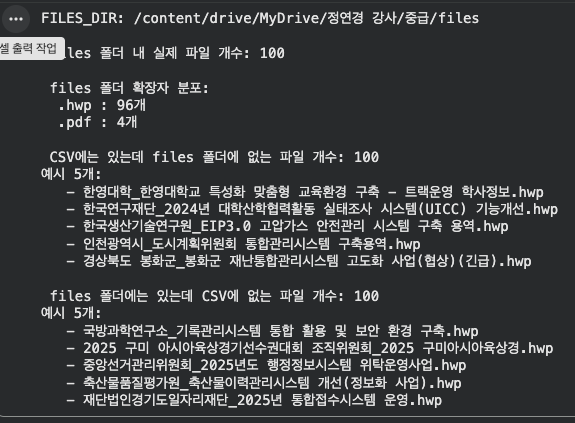
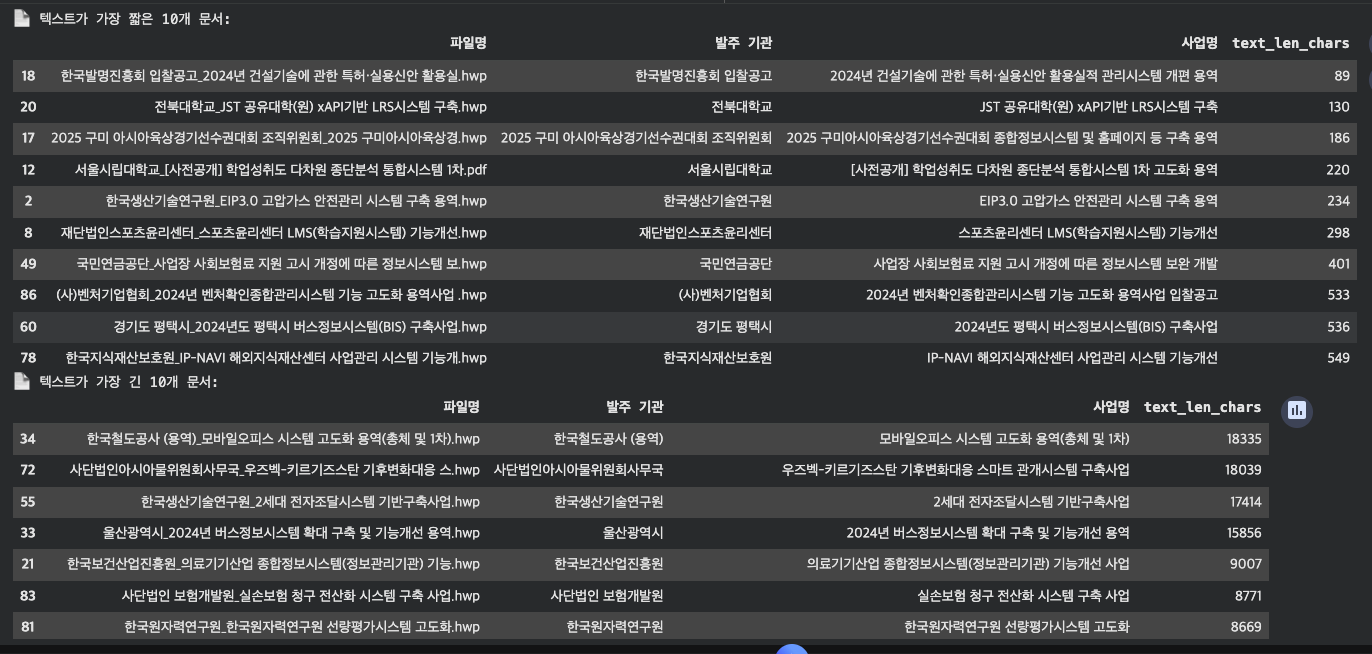

### CSV 중복 전수조사

In [6]:
# ==============================================================================
# [0. 사전 준비] 모든 정규화 및 전처리 작업 일괄 수행
# ==============================================================================
# 1) 텍스트/요약 정규화 (공백, 특수문자 제거)
df['text_norm'] = df['텍스트'].fillna('').apply(lambda x: re.sub(r'\s+', '', str(x).strip().lower()))
df['summary_norm'] = df['사업 요약'].fillna('').apply(lambda x: re.sub(r'\s+', '', str(x).strip().lower()))

# 2) 파일명 정규화 (복사본 접미사 제거)
df['filename_norm'] = df['파일명'].astype(str).apply(lambda x: re.sub(r'[\(\[\{\_\-]\s*\d+\s*[\)\]\}]|\s*copy', '', x.lower()))

# 3) 날짜 변환
df['공개일_dt'] = pd.to_datetime(df['공개 일자'], errors='coerce')
df['마감일_dt'] = pd.to_datetime(df['입찰 참여 마감일'], errors='coerce')

# 4) 확장자 무시 파일명 (Stem) 추출
df['file_stem'] = df['파일명'].astype(str).apply(lambda x: os.path.splitext(x)[0])
df['file_stem_norm'] = df['file_stem'].apply(lambda x: re.sub(r'\s+', '', x.strip().lower()))

# 5) 기관명/사업명 세탁 (위장술 적발용)
def clean_agency(text):
    text = str(text).lower()
    text = re.sub(r'\([^)]*\)', '', text) # 괄호 제거
    text = re.sub(r'주식회사|사단법인|재단법인|유한회사|공사|진흥원|연구원', '', text) # 법인격 제거
    text = re.sub(r'[^가-힣a-z0-9]', '', text) # 특수문자 제거
    return text

df['agency_clean'] = df['발주 기관'].apply(clean_agency)
df['title_clean'] = df['사업명'].apply(lambda x: re.sub(r'\s+', '', str(x).lower()))


# ==============================================================================
# [1. 전체 컬럼 완전 일치] 12개 컬럼이 모두 똑같은 경우
# ==============================================================================
print("\n[1. 전체 컬럼 완전 일치 검사]")
full_dups = df[df.duplicated(keep=False)]

print(f"발견된 데이터: {len(full_dups)}개")

if len(full_dups) > 0:
    print("-" * 80)
    print(full_dups[['사업명', '발주 기관', '사업 금액', '파일명']].sort_values(by='사업명'))
    print("\n진단: 위 데이터들은 모든 정보가 100% 동일하므로 중복 제거 대상")
else:
    print("이상 없음 (12개 컬럼이 모두 동일한 데이터는 없음)")


# ==============================================================================
# [2. 사업명 중복 심층 분석]
# ==============================================================================
print("\n" + "=" * 80)
print("[2. 사업명 중복 분석 (동명이인 식별) - 정밀판]")

# 원본 '사업명' 대신 정규화된 'title_clean' 사용
# title_clean은 공백/특수문자가 제거된 버전 (예: "통합정보시스템고도화용역")
title_dups = df[df.duplicated(subset=['title_clean'], keep=False)]

print(f"사업명이 중복된 데이터: {len(title_dups)}개")

if len(title_dups) > 0:
    print("-" * 80)
    # 정규화된 이름으로 그룹핑
    grouped = title_dups.groupby('title_clean')
    
    for clean_title, group in grouped:
        # 대표 사업명 하나 가져오기 (출력용)
        display_title = group['사업명'].iloc[0]
        print(f"[사업명 그룹] : {display_title}")
        
        cols_to_compare = ['발주 기관', '공고 번호', '사업 금액', '공개 일자', '파일명']
        display_df = group[cols_to_compare].copy()
        
        for idx, row in display_df.iterrows():
            print(f"   [Index {idx}]")
            print(f"      - 발주 기관 : {row['발주 기관']}")
            print(f"      - 사업 금액 : {row['사업 금액']:,.0f}원")
            print(f"      - 공고 번호 : {row['공고 번호']}")
            print(f"      - 공개 일자 : {row['공개 일자']}")
            
        agencies = group['발주 기관'].unique()
        if len(agencies) > 1:
            print(f"   -> [분석결과] '발주 기관'이 다름 ({', '.join(agencies)})")
            print(f"      (서로 다른 기관이 같은 이름의 사업을 발주함 -> 표절 또는 흔한 사업명)")
        else:
            print(f"   -> [분석결과] 발주 기관까지 동일함 (중복 또는 재공고)")
        print("-" * 40)
else:
    print("사업명이 겹치는 데이터가 없음")


# ==============================================================================
# [3. 유형별 상세 중복 리포트]
# ==============================================================================
print("\n" + "=" * 80)
print("[3. 유형별 상세 중복 리포트]")

def report_duplicates(dataframe, subset_cols, check_name, filter_condition=None):
    if filter_condition is not None:
        target_df = dataframe[filter_condition].copy()
    else:
        target_df = dataframe.copy()
        
    dups = target_df[target_df.duplicated(subset=subset_cols, keep=False)]
    count = len(dups)
    
    print(f"\n[{check_name}] 발견된 데이터: {count}개")
    
    if count > 0:
        print("-" * 80)
        grouped = dups.groupby(subset_cols)
        group_id = 1
        for key, group in grouped:
            print(f"[Group {group_id}] 중복 키값: {key}")
            for idx, row in group.iterrows():
                print(f"      [Index {idx}] 기관: {row['발주 기관']} | 사업명: {row['사업명']} | 금액: {row['사업 금액']:,.0f}원 | 파일명: {row['파일명']}")
            print("-" * 40)
            group_id += 1
    else:
        print("이상 없음")

# 3-1. 절대적 중복
print("\n--- A. 절대적 중복 검사 ---")
report_duplicates(df, ['text_norm'], "본문 내용 완전 일치", df['text_norm'].str.len() > 50)
report_duplicates(df, ['공고 번호'], "공고 번호(ID) 중복", df['공고 번호'].notnull())
report_duplicates(df, ['파일명'], "파일명 중복")
report_duplicates(df, ['summary_norm'], "요약문 중복", df['summary_norm'].str.len() > 10)

# 3-2. 논리적 중복
print("\n--- B. 논리적 중복 검사 ---")
report_duplicates(df, ['발주 기관', '사업명'], "기관 + 사업명 동일")
report_duplicates(df, ['사업명', '사업 금액'], "사업명 + 금액 동일", df['사업 금액'] > 0)

# 3-3. 구조적 중복 (파일/기관명 변형)
print("\n--- C. 구조적 변형 탐지 ---")

# (1) 파일명 복사본 탐지
mask_norm_dup = df.duplicated(subset=['filename_norm'], keep=False)
mask_exact_dup = df.duplicated(subset=['파일명'], keep=False)
pure_norm_dup = mask_norm_dup & (~mask_exact_dup)

if pure_norm_dup.sum() > 0:
    print(f"\n[파일명 변형(복사본)] 발견된 데이터: {pure_norm_dup.sum()}개")
    for key, group in df[pure_norm_dup].groupby('filename_norm'):
        print(f"[Group] 정규화된 파일명: {key}")
        for idx, row in group.iterrows():
            print(f"      [Index {idx}] 파일명: {row['파일명']}")
else:
    print("\n[파일명 변형(복사본)] 이상 없음")

# (2) 확장자만 다른 파일 탐지 (.hwp vs .pdf)
stem_dups = df[df.duplicated(subset=['file_stem_norm'], keep=False)]
if len(stem_dups) > 0:
    grouped = stem_dups.groupby('file_stem_norm')
    found_real_dup = False
    print("-" * 80)
    for stem, group in grouped:
        if len(group['파일명'].unique()) > 1:
            found_real_dup = True
            print(f"[확장자 차이 그룹] 파일명 몸통: {stem}")
            for idx, row in group.iterrows():
                print(f"      [Index {idx}] 파일명: {row['파일명']}")
            print("-" * 40)
    if not found_real_dup:
        print("[확장자 차이] 이상 없음 (파일명이 완전히 같은 중복만 존재)")
else:
    print("[확장자 차이] 이상 없음")

# (3) 기관명 위장술 탐지 ((주)한국전력 vs 한국전력공사)
hidden_dups = df[df.duplicated(subset=['agency_clean', 'title_clean'], keep=False)]
if len(hidden_dups) > 0:
    grouped = hidden_dups.groupby(['agency_clean', 'title_clean'])
    real_hidden_found = False
    for _, group in grouped:
        if len(group['발주 기관'].unique()) > 1:
            real_hidden_found = True
            print(f"[기관명 표기 차이 그룹]")
            for idx, row in group.iterrows():
                print(f"      [Index {idx}] 기관: {row['발주 기관']} (세탁후: {row['agency_clean']}) | 사업명: {row['사업명']}")
            print("-" * 40)
    if not real_hidden_found:
        print("\n[기관명 표기 차이] 이상 없음 (세탁 후에도 숨겨진 중복 없음)")
else:
    print("\n[기관명 표기 차이] 이상 없음")


# ==============================================================================
# [4. 시간적 중복 검사] 같은 기관 내 기간 겹침
# ==============================================================================
print("\n" + "=" * 80)
print("[4. 시간적 중복 검사 (기간 겹침)]")

time_dups = []
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if df.iloc[i]['발주 기관'] != df.iloc[j]['발주 기관']: continue
        if pd.isna(df.iloc[i]['공개일_dt']) or pd.isna(df.iloc[i]['마감일_dt']): continue
        if pd.isna(df.iloc[j]['공개일_dt']) or pd.isna(df.iloc[j]['마감일_dt']): continue
        
        start1, end1 = df.iloc[i]['공개일_dt'], df.iloc[i]['마감일_dt']
        start2, end2 = df.iloc[j]['공개일_dt'], df.iloc[j]['마감일_dt']
        
        if start1 < end2 and end1 > start2:
            time_dups.append((i, j))

print(f"\n[기간 겹침] 발견된 쌍: {len(time_dups)}쌍")

if len(time_dups) > 0:
    print("-" * 80)
    for idx1, idx2 in time_dups:
        row1 = df.iloc[idx1]
        row2 = df.iloc[idx2]
        print(f"    [Group] 기관: {row1['발주 기관']}")
        print(f"      -> [Index {idx1}] {row1['사업명']} ({str(row1['공개일_dt'])[:10]} ~ {str(row1['마감일_dt'])[:10]})")
        print(f"      -> [Index {idx2}] {row2['사업명']} ({str(row2['공개일_dt'])[:10]} ~ {str(row2['마감일_dt'])[:10]})")
        print("-" * 40)
else:
    print("이상 없음")

# 뒷정리
cleanup_cols = ['text_norm', 'summary_norm', 'filename_norm', '공개일_dt', '마감일_dt', 'file_stem', 'file_stem_norm', 'agency_clean', 'title_clean']
for c in cleanup_cols:
    if c in df.columns: del df[c]

print("\n" + "=" * 80)
print("검사 완료")


[1. 전체 컬럼 완전 일치 검사]
발견된 데이터: 0개
이상 없음 (12개 컬럼이 모두 동일한 데이터는 없음)

[2. 사업명 중복 분석 (동명이인 식별) - 정밀판]
사업명이 중복된 데이터: 2개
--------------------------------------------------------------------------------
[사업명 그룹] : 통합정보시스템 고도화 용역
   [Index 15]
      - 발주 기관 : 국가과학기술지식정보서비스
      - 사업 금액 : 140,000,000원
      - 공고 번호 : nan
      - 공개 일자 : 2024-05-30 00:00:00
   [Index 53]
      - 발주 기관 : 한국한의학연구원
      - 사업 금액 : 140,000,000원
      - 공고 번호 : 20240535775
      - 공개 일자 : 2024-05-30 09:04:12
   -> [분석결과] '발주 기관'이 다름 (국가과학기술지식정보서비스, 한국한의학연구원)
      (서로 다른 기관이 같은 이름의 사업을 발주함 -> 표절 또는 흔한 사업명)
----------------------------------------

[3. 유형별 상세 중복 리포트]

--- A. 절대적 중복 검사 ---

[본문 내용 완전 일치] 발견된 데이터: 0개
이상 없음

[공고 번호(ID) 중복] 발견된 데이터: 0개
이상 없음

[파일명 중복] 발견된 데이터: 0개
이상 없음

[요약문 중복] 발견된 데이터: 0개
이상 없음

--- B. 논리적 중복 검사 ---

[기관 + 사업명 동일] 발견된 데이터: 0개
이상 없음

[사업명 + 금액 동일] 발견된 데이터: 2개
--------------------------------------------------------------------------------
[Group 1] 중복 키값: ('통합정보시스템 고도화 용역', 140000000.0)
 

- 분석
    - 텍스트 정규화(Normalization) 및 규칙 기반(Rule-based) 알고리즘을 적용하여 데이터의 중복 여부를 전수 조사함 검사 결과 데이터의 유니크성은 전반적으로 우수하나 1건의 확실한 중복(Logical Duplicate)이 발견됨 육안으로 확인 결과 단순 파일명 중복이 아닌 서로 다른 기관명을 사용하여 등록된 동일 공고로 판명되어 삭제(Drop) 조치가 필요함
    - 2.1. 분석 방법론 (Methodology)
        - 단순 문자열 일치가 아닌 위장된 중복을 찾기 위해 다음과 같은 전처리 후 비교를 수행함
            - Agency Cleaning: 법인격(주식회사, 재단법인 등) 및 괄호 제거 후 비교
            - Text Normalization: 공백 및 특수문자 제거 (통합 정보 시스템 == 통합정보시스템)
            - Key Combination: [사업명 + 예산], [기관 + 기간] 등 복합 키 활용
    - 2.2. 검출된 중복 사례 (Critical Findings)
        - 전체 100건 중 단 1쌍(2건)의 논리적 중복이 발견됨
            - 통합정보시스템 고도화 용역
                - 한국한의학연구원
                - 국가과학기술지식정보서비스
            - 상세 분석
                - 두 건은 사업명, 금액(140,000,000원), 공개일자(5월 30일)가 완벽히 일치함
                - 국가과학기술지식정보서비스(NTIS)는 해당 사업이 수행될 시스템의 이름이며 실제 발주를 낸 행정 기관은 한국한의학연구원임 즉 Index 15는 발주 기관명이 잘못 기재된(시스템명으로 기재된) 중복 데이터임
                - 파일 내용을 육안 확인한 결과 100% 동일한 문서임
    - 2.3. 기타 검사 결과
        - 물리적 중복(파일명/본문 완전 일치): 발견되지 않음 (0건)
        - 시간적 중복(기간 겹침): 발견되지 않음
        - 구조적 변형(확장자 차이 등): 발견되지 않음

- 결정 사항: 'Blacklist' 기반 필터링
    - EDA 과정에서 데이터를 즉시 삭제하지 않고 제거 대상 목록(Blacklist)을 생성하여 관리한다
        - 제거 대상: Index 15 (국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp)
        - 보존 대상: Index 53 (한국한의학연구원_통합정보시스템 고도화 용역.hwp)
        - [Config] 데이터 로드 시 제거할 블랙리스트 정의
            - DROP_INDICES = [15]  # Index 15: 중복 데이터(Index 53의 하위 호환)

- 현재까지의 상황 정리:
    - 무결성 검증: 파일 1개 손상 복구 완료
    - 데이터 오염: 공고번호 결측 18건 수기 보완 완료 추가 문서(공고문, 과업지시서, 기타 문서) 확보
    - 중복 검사: Index 15번 뒤에서 논의 후 아예 제거하기로 결정했음

### CSV 논리적 모순 전수조사

In [ ]:
def report_issues(issue_list, check_name):
    count = len(issue_list)
    print(f"\n[{check_name}] 발견된 문제: {count}건")
    if count > 0:
        print("-" * 80)
        for item in issue_list:
            print(f"   ▶ [Index {item['row_idx']}] {item['project_name']}")
            print(f"      오류 내용: {item['message']}")
            if item.get('details'):
                print(f"      상세 정보: {item['details']}")
            print("-" * 40)
    else:
        print("   이상 없음")

# 날짜 변환 함수 개선
def safe_date_convert(date_str):
    if pd.isna(date_str): return None
    date_str = str(date_str).strip()
    
    # 1. 원본 문자열 그대로 변환 시도 
    # (예: '2024-10-15 17:00:00' 같은 표준 포맷은 여기서 바로 성공)
    try:
        return pd.to_datetime(date_str)
    except:
        pass # 실패하면 아래 2번(청소) 단계로 넘어감

    # 2. [2차 시도] 한글이나 특수문자가 섞인 경우 청소 후 변환
    # (예: "2024년 10월 15일" -> "20241015")
    cleaned = re.sub(r'[년월일]', '', date_str)    # 한글 제거
    cleaned = re.sub(r'[-/.]', '', cleaned)       # 구분자 제거
    cleaned = re.sub(r'\s.*', '', cleaned)        # 시간 정보(공백 뒤)가 복잡하면 날짜만 남김
    
    try: return pd.to_datetime(cleaned, errors='coerce')
    except: return None

# 날짜 변환 적용
df['공개일_dt'] = df['공개 일자'].apply(safe_date_convert)
df['시작일_dt'] = df['입찰 참여 시작일'].apply(safe_date_convert)
df['마감일_dt'] = df['입찰 참여 마감일'].apply(safe_date_convert)


# [1] 파일 및 텍스트 구조 모순
print("\n" + "="*80)
print("1. 파일 및 텍스트 구조 분석")
print("="*80)

# 1-1. 확장자 불일치
issues = []
ext_mapping = {'hwpx': 'hwp', 'pdf': 'pdf', 'docx': 'doc', 'doc': 'doc', 'xlsx': 'xls', 'xls': 'xls', 'pptx': 'ppt', 'ppt': 'ppt', 'txt': 'txt'}
for idx, row in df.iterrows():
    filename = str(row['파일명']).lower()
    filetype = str(row['파일형식']).lower()
    if '.' in filename: actual_ext = filename.split('.')[-1]
    else: actual_ext = '없음'
    
    norm_actual = ext_mapping.get(actual_ext, actual_ext)
    norm_filetype = ext_mapping.get(filetype, filetype)
    
    if norm_actual != norm_filetype:
        issues.append({
            'row_idx': idx, 'project_name': row['사업명'], 
            'message': f"확장자는 '{actual_ext}'인데, 파일형식은 '{filetype}'로 기재됨",
            'details': f"파일명: {row['파일명']}"
        })
report_issues(issues, "1-1. 파일 확장자 vs 파일형식 불일치")

# 1-2. 의심스러운 파일명
issues = []
suspicious_keywords = ['temp', 'tmp', 'copy', '복사본', 'new', '새파일'] 
meaningless_names = ['', 'nan', 'null', 'undefined', '파일없음', '미제출']
for idx, row in df.iterrows():
    filename = str(row['파일명']).lower()
    msg = []
    if filename in meaningless_names: msg.append(f"무의미한 파일명('{filename}')")
    found_k = [k for k in suspicious_keywords if k in filename]
    if found_k: msg.append(f"임시 파일 의심 단어 포함({', '.join(found_k)})")
    
    clean_len = len(filename.replace('.', ''))
    if clean_len < 5: msg.append(f"파일명이 너무 짧음({clean_len}자)")
    
    special_chars = sum(1 for c in filename if c in '!@#$%^&*()_+={}[]|\\:;"\'<>?~`')
    if special_chars > 4: msg.append(f"특수문자 과다 포함({special_chars}개)")
        
    if msg: 
        issues.append({
            'row_idx': idx, 'project_name': row['사업명'], 
            'message': " / ".join(msg), 'details': f"파일명: {row['파일명']}"
        })
report_issues(issues, "1-2. 의심스러운 파일명 패턴")

# 1-3. RFP 문서 맥락 및 길이 검사
print("\n[1-3. 문서 내용 정합성 및 길이 검사]")
issues = []
rfp_keywords = ['제안', '요청', '과업', '지시', '사업', '개요', '목차', '시스템', '구축', '용역', '유지보수', '목적', '범위', '내용']

for idx, row in df.iterrows():
    text = str(row['텍스트'])
    
    if len(text) < 100:
        issues.append({
            'row_idx': idx, 'project_name': row['사업명'],
            'message': f"텍스트 내용이 {len(text)}자로 너무 짧음 (100자 미만)",
            'details': "파싱 실패 또는 빈 문서 의심"
        })
        continue 

    if len(text) > 6000:
        issues.append({
            'row_idx': idx, 'project_name': row['사업명'],
            'message': f"텍스트 내용이 {len(text)}자로 너무 김 (6,000자 초과)",
            'details': "파일 병합 오류 또는 비정상 데이터 의심"
        })

    text_start = text[:2000]
    found_keywords = [k for k in rfp_keywords if k in text_start]
    
    if len(found_keywords) < 2:
        issues.append({
            'row_idx': idx, 'project_name': row['사업명'],
            'message': f"필수 키워드가 {len(found_keywords)}개 밖에 없음 (기준 2개 이상)",
            'details': f"발견된 키워드: {found_keywords if found_keywords else '없음'}"
        })
report_issues(issues, "1-3. 문서 내용 길이 및 정합성")


# [2] 시간/업무 규칙 모순
print("\n" + "="*80)
print("2. 시간 및 업무 규칙(Business Rule) 위반 분석")
print("="*80)

issues_time = []
issues_weekend = []
issues_order = []
issues_emergency = []

for idx, row in df.iterrows():
    open_d, start_d, end_d = row['공개일_dt'], row['시작일_dt'], row['마감일_dt']
    title = str(row['사업명'])
    
    f_open = open_d.strftime('%Y-%m-%d') if pd.notna(open_d) else "None"
    f_start = start_d.strftime('%Y-%m-%d') if pd.notna(start_d) else "Invalid(NaT)"
    f_end = end_d.strftime('%Y-%m-%d') if pd.notna(end_d) else "None"

    date_info_str = f"공개:{f_open} / 시작:{f_start} / 마감:{f_end}"

    # 2-1. 날짜 역행/기간 오류
    errs = []
    
    raw_start = str(row.get('입찰 참여 시작일', '')).strip()
    raw_end = str(row.get('입찰 참여 마감일', '')).strip()
    
    # 원본값은 있는데 변환 결과가 NaT인 경우만 오류로 잡음
    if pd.isna(start_d) and len(raw_start) > 0 and raw_start.lower() not in ['nan', 'none']:
         errs.append(f"시작일 날짜 형식 불능('{raw_start}')")
    if pd.isna(end_d) and len(raw_end) > 0 and raw_end.lower() not in ['nan', 'none']:
         errs.append(f"마감일 날짜 형식 불능('{raw_end}')")

    if pd.notna(open_d) and pd.notna(end_d) and open_d > end_d: 
        errs.append(f"공개일이 마감일보다 늦음")
    if pd.notna(start_d) and pd.notna(end_d) and start_d > end_d: 
        errs.append(f"시작일이 마감일보다 늦음")
    if pd.notna(open_d) and pd.notna(start_d) and open_d > start_d: 
        errs.append(f"공개일이 시작일보다 늦음")
        
    if pd.notna(start_d) and pd.notna(end_d):
        diff = (end_d - start_d).days
        if diff < 1: errs.append(f"입찰 기간({diff}일)이 비정상적으로 짧음")
        elif diff > 365: errs.append(f"입찰 기간({diff}일)이 비정상적으로 김")
            
    if errs: 
        issues_time.append({
            'row_idx': idx, 'project_name': row['사업명'], 
            'message': " / ".join(errs), 
            'details': date_info_str
        })

    # 2-2. 주말 마감 체크
    if pd.notna(end_d):
        if end_d.weekday() >= 5:
            day_name = '토요일' if end_d.weekday() == 5 else '일요일'
            issues_weekend.append({
                'row_idx': idx, 'project_name': row['사업명'],
                'message': f"입찰 마감일이 휴일({day_name})임",
                'details': f"마감일: {f_end}"
            })

    # 2-3. 재공고 차수 논리
    if '공고 차수' in df.columns and pd.notna(row['공고 차수']):
        order = float(row['공고 차수'])
        is_re_notice = any(k in title for k in ['재공고', '재입찰'])
        if is_re_notice and order == 0:
            issues_order.append({
                'row_idx': idx, 'project_name': row['사업명'],
                'message': "재공고/재입찰인데 공고 차수가 '0'(초안)",
                'details': f"차수: {order}"
            })

    # 2-4. 긴급 입찰 적정성
    if pd.notna(start_d) and pd.notna(end_d):
        duration = (end_d - start_d).days
        is_emergency_title = '긴급' in title
        if duration > 0 and duration < 5 and not is_emergency_title:
            issues_emergency.append({
                'row_idx': idx, 'project_name': row['사업명'],
                'message': f"입찰 기간({duration}일)이 매우 짧은데 '긴급' 표시가 없음",
                'details': f"기간: {duration}일"
            })

report_issues(issues_time, "2-1. 타임라인 오류 (형식불능 포함)")
report_issues(issues_weekend, "2-2. 휴일(주말) 마감일 설정")
report_issues(issues_order, "2-3. 재공고 차수 논리 모순")
report_issues(issues_emergency, "2-4. 입찰 기간 vs 긴급 여부 모순")


# [3] 금액 모순 (통계적 이상치 포함)
print("\n" + "="*80)
print("3. 금액 논리 모순 및 이상치 분석")
print("="*80)

issues_amt = []
issues_stats = []

agency_stats = df.groupby('발주 기관')['사업 금액'].agg(['mean', 'std', 'count'])
agency_stats = agency_stats[agency_stats['count'] >= 3]

for idx, row in df.iterrows():
    amt = row['사업 금액']
    agency = row['발주 기관']
    
    if pd.isna(amt): continue
    
    msg = ""
    if amt < 0: msg = f"음수 금액 ({amt:,.0f}원)"
    elif amt == 0: msg = "금액이 0원임"
    elif amt % 1000 == 0 and amt % 10000 != 0: msg = f"의심스러운 반올림 패턴 ({amt:,.0f}원)"
    elif amt < 5000000: msg = f"금액 과소 ({amt:,.0f}원 < 500만원)"
    elif amt > 100000000000: msg = f"금액 과대 ({amt:,.0f}원 >= 1000억)"
    
    if msg: 
        issues_amt.append({
            'row_idx': idx, 'project_name': row['사업명'], 
            'message': msg, 'details': f"기재된 금액: {amt:,.0f}원"
        })

    if amt > 0 and agency in agency_stats.index:
        avg = agency_stats.loc[agency, 'mean']
        std = agency_stats.loc[agency, 'std']
        if std > 0:
            z_score = (amt - avg) / std
            if abs(z_score) > 3:
                issues_stats.append({
                    'row_idx': idx, 'project_name': row['사업명'],
                    'message': f"기관 평균 대비 금액 비정상 (Z-Score: {z_score:.1f})",
                    'details': f"기관평균: {avg:,.0f}원 vs 본건: {amt:,.0f}원"
                })

report_issues(issues_amt, "3-1. 사업 금액 절대적 오류")
report_issues(issues_stats, "3-2. 기관별 예산 통계 이상치 (3-Sigma)")


# [4] 텍스트 모순
print("\n" + "="*80)
print("4. 텍스트 내용 논리 모순 분석")
print("="*80)

def extract_budget_smart(text):
    text = str(text).replace(' ', '')
    amounts = []
    
    for x in re.findall(r'(\d{1,3}(?:,\d{3})+)원', text):
        amounts.append(int(x.replace(',', '')))
    for x in re.findall(r'(\d{7,})원', text):
        amounts.append(int(x))
    
    unit_map = {'억': 100000000, '천만': 10000000, '백만': 1000000, '십만': 100000, '만': 10000}
    
    for match in re.findall(r'(\d+)억(\d+)?(천만|백만|십만|만)?원', text):
        val = int(match[0]) * unit_map['억']
        if match[1] and match[2]:
            val += int(match[1]) * unit_map[match[2]]
        amounts.append(val)
    
    for num, unit in re.findall(r'(\d+)(천만|백만|십만|만)원', text):
        amounts.append(int(num) * unit_map[unit])
    
    return amounts if amounts else []

issues = []
issues_context = []

for idx, row in df.iterrows():
    txt, meta = str(row['텍스트']), row['사업 금액']
    title = str(row['사업명'])
    summary = str(row['사업 요약'])
    
    if pd.notna(meta) and meta > 0:
        found_amounts = extract_budget_smart(txt)
        if found_amounts:
            closest_amt = min(found_amounts, key=lambda x: abs(x - meta))
            if closest_amt != meta:
                issues.append({
                    'row_idx': idx, 'project_name': row['사업명'],
                    'message': f"금액 불일치 (차이: {abs(closest_amt - meta):,}원)",
                    'details': f"메타: {meta:,.0f}원 vs 본문(유사값): {closest_amt:,.0f}원"
                })
    
    if len(summary) >= 10:
        clean_title = re.sub(r'[\[\]\(\)]', ' ', title)
        keywords = [w for w in clean_title.split() if len(w) >= 2]
        match_count = sum(1 for k in keywords if k in summary)
        if len(keywords) > 0 and match_count == 0:
            issues_context.append({
                'row_idx': idx, 'project_name': row['사업명'],
                'message': "사업명 핵심 키워드가 요약문에 없음",
                'details': f"키워드: {keywords[:3]}..."
            })

report_issues(issues, "4-1. 텍스트 금액 정합성")
report_issues(issues_context, "4-2. 사업명 vs 요약문 일치성")


# [5] 공고번호 모순
print("\n" + "="*80)
print("5. 공고 번호 논리 모순 분석")
print("="*80)
curr_year = datetime.now().year
issues = []
for idx, row in df.iterrows():
    id_v = str(row['공고 번호']).strip()
    open_d = row['공개일_dt']
    if id_v.lower() in ['nan', 'none', '']: continue
    msg = []
    
    if len(id_v) < 8 or len(id_v) > 15: msg.append(f"길이 비정상({len(id_v)}자리)")
    if not re.match(r'^\d{4}[-]?\d+$', id_v): msg.append("패턴 비정상")
    else:
        id_year = int(id_v[:4])
        if id_year < 2000 or id_year > curr_year + 1: msg.append(f"연도 비정상({id_year}년)")
        if pd.notna(open_d):
            open_year = open_d.year
            if abs(id_year - open_year) > 1: msg.append(f"번호연도({id_year}) vs 공개연도({open_year}) 불일치")
    if msg: issues.append({'row_idx': idx, 'project_name': row['사업명'], 'message': " / ".join(msg), 'details': f"공고번호: {id_v}"})
report_issues(issues, "5-1. 공고 번호 유효성 및 논리")

# 뒷정리
for c in ['공개일_dt', '시작일_dt', '마감일_dt']:
    if c in df.columns: del df[c]

print("\n" + "="*80)
print("검사 완료")


1. 파일 및 텍스트 구조 분석

[1-1. 파일 확장자 vs 파일형식 불일치] 발견된 문제: 0건
   이상 없음

[1-2. 의심스러운 파일명 패턴] 발견된 문제: 10건
--------------------------------------------------------------------------------
   ▶ [Index 4] 봉화군 재난통합관리시스템 고도화 사업(협상)(긴급)
      오류 내용: 특수문자 과다 포함(5개)
      상세 정보: 파일명: 경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp
----------------------------------------
   ▶ [Index 25] 아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아)사업 PMC 용역
      오류 내용: 특수문자 과다 포함(5개)
      상세 정보: 파일명: 한국농어촌공사_아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아.hwp
----------------------------------------
   ▶ [Index 26] [긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 국회 방송시스템 구축 및 지역의회 연계 개선 PMC 용역
      오류 내용: 특수문자 과다 포함(7개)
      상세 정보: 파일명: KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp
----------------------------------------
   ▶ [Index 34] 모바일오피스 시스템 고도화 용역(총체 및 1차)
      오류 내용: 특수문자 과다 포함(5개)
      상세 정보: 파일명: 한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp
----------------------------------------
   ▶ [Index 46] 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)
      오류 

In [10]:
print(df['공고 차수'].value_counts(dropna=False).sort_index())

zero_order = df[df['공고 차수'] == 0]

print(f"차수가 '0'으로 기재된 데이터: 총 {len(zero_order)}")
print(zero_order[['사업명', '공고 차수', '공고 번호']])

공고 차수
0.0    76
1.0     4
2.0     2
NaN    18
Name: count, dtype: int64
차수가 '0'으로 기재된 데이터: 총 76
                                               사업명  공고 차수        공고 번호
0         한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화    0.0  20241001798
1               2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선    0.0  20241002912
2                       EIP3.0 고압가스 안전관리 시스템 구축 용역    0.0  20240827859
3                             도시계획위원회 통합관리시스템 구축용역    0.0  20240430918
4                     봉화군 재난통합관리시스템 고도화 사업(협상)(긴급)    0.0  20240430896
..                                             ...    ...          ...
95                  적십자병원 병원정보 재해복구시스템 구축 용역 재공고입찰    0.0  20240409322
96                  수문자료정보관리시스템(HDIMS) 재구축 용역(3단계)    0.0  20240409641
97                              통합 정보시스템 구축 사전 컨설팅    0.0  20240419826
98  2024년 광주문화예술통합플랫폼 시스템 유지 및 보수 용역 제안서 제출 안내 재공고    0.0  20240419765
99             스마트 팹 서비스 활용체계 구축관련 설비온라인 시스템 구축 용역    0.0  20240420207

[76 rows x 3 columns]


- 분석
  - 1. 로직 내용
    - 타임라인 분석 'diff < 1' 조건으로 ‘기간 0일’ 데이터를 잡아내어 단순 오류가 아닌 수의계약/긴급공고임을 밝혀냄
    - 금액 로직 'extract_budget_smart' 함수로 한글 금액도 파싱하여 CSV 메타데이터와 교차 검증 했음
    - 공고 차수 'value_counts' 결과 대부분이 ‘0’임을 확인 실제로 나라장터에서 확인 결과 나라장터 시스템이 재공고 시 번호를 새로 발급(차수 초기화)함을 알게됨(여기서 우리는 공고 차수는 사실 쓸모가 없다는걸 알게됨)
    - ID 패턴 'R25BK' 패턴을 탐지하여 해당 문서들이 대부분이 나라장터가 아닌 기관 내부 공고번호임을 식별함

  - 2. 정합성 검증 상세 결과 (Fact Check)
      - 2.1. 파일 및 메타데이터 검증  
        - 파일 확장자 vs 파일형식 이상없음 확인함 
        - 파일명 중복 문자 이상 없음 시스템 처리에 영향 없음  
        - 텍스트 길이는 극단치 너무 짧은 경우(HWP 파싱 실패)나 너무 긴 경우(대형 RFP)는 단순 데이터 특성 텍스트 컬럼만으로는 의미가 부족함 결론으로는 텍스트 컬럼을 쓰는 의미가 없음을 확인함
        
      - 2.2. 입찰 기간 및 마감일  
          - 짧은 입찰기간: 수의계약/긴급공고로 확인  
          - 휴일(주말) 마감일: 이상 없음 정상 패턴
        
      - 2.3. 예산(Budget) 데이터  
        - 현상: '0원', '1원', 불일치 다수  
        - 분석: 
          - '0원/1원': 단순 누락이 아니라 사전 규격 공개 또는 협상계약 단계라 예상(우리는 이게 수의계약이라는 것을 확인했음)  
          - 불일치: CSV는 VAT 별도, 원본은 VAT 포함 또는 반올림 차이
          - 이상한 반올림 패턴은 입찰 깎아서 다시 올리는 경우가 있음 그 경우 % 단위로 깎일 수 있음 또한 소프트웨어의 경우에는 기술자 월 단가와 투입기간, 투입율에 따라 계산이 되어 깔끔하게 안떨어지는 경우가 있음을 확인함
        
        - 2.4. 공고 차수(Order) 
          - 대부분 '0'으로 확인 → 재공고 시 새 번호 발급으로 차수 초기화
          - 결론: 공고 차수는 최신성 판단 기준이 될 수 없음(재공고 시 초기화됨 공고 차수는 쓸모 없음)
        
        - 2.5. ID 패턴  
          - 'R25BK...' → 입찰 공고 번호가 아닌 RFP 등록 번호이거나 기관 내부에서 사용되는 공고번호  
          - 조치: 우리는 뒤에서 사실상 공고 번호를 사용하지 않기로 하고 사업별로 Project id를 부여해줬음 대신 공고번호는 결측치를 채우려 나라장터를 찾아다닐때 굉장히 유용하게 사용했음

### CSV 유사도 분석

In [ ]:
# ==============================================================================
# [설정] 그물망 임계값
# ==============================================================================
SEMANTIC_THRESHOLD = 0.85   # 의미가 85% 이상 같아야 잡음
TFIDF_THRESHOLD = 0.85      # 단어가 85% 이상 같아야 잡음
TITLE_DIST_THRESHOLD = 0.90 # 제목은 90% 오타 수준만 잡음

# [설정] 리포트 출력 함수
def report_issues(issue_list, check_name):
    count = len(issue_list)
    print(f"\n[{check_name}] 발견된 문제: {count}건")
    if count > 0:
        print("-" * 80)
        for item in issue_list:
            idx_str = str(item['row_idx'])
            print(f"   ▶ [Index {idx_str}]")
            print(f"      {item['project_name']}")
            print(f"      [진단]: {item['message']}")
            if item.get('details'):
                print(f"      [상세]: {item['details']}")
            print("-" * 40)
    else:
        print("   특이사항 없음")

# ==============================================================================
# [실행] 통합 분석 시작
# ==============================================================================
print("[초기화] AI 분석 모델 로딩 중", end="")
model = SentenceTransformer('jhgan/ko-sroberta-multitask')
print(" 완료")

# 0. 데이터 전처리 (전체 통합 텍스트 생성)
titles = df['사업명'].fillna("").astype(str).tolist()
agencies = df['발주 기관'].fillna("").astype(str).tolist()
# 제목 + 요약 + 텍스트 = 전체 문맥(Context)
contexts = (df['사업명'].fillna("") + " " + df['사업 요약'].fillna("") + " " + df['텍스트'].fillna("")).tolist()


# ------------------------------------------------------------------------------
# 1. [유사도 분석] 조금이라도 비슷하면 다 검거
# ------------------------------------------------------------------------------

# A. 의미(Meaning) 벡터화
embeddings = model.encode(contexts, show_progress_bar=False)
sim_semantic = cosine_similarity(embeddings)

# B. 패턴(Pattern) 벡터화
tfidf_vec = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
tfidf_matrix = tfidf_vec.fit_transform(contexts)
sim_tfidf = cosine_similarity(tfidf_matrix)

issues_similarity = []
n = len(df)

for i in range(n):
    for j in range(i + 1, n):
        
        # 점수 계산
        s_score = sim_semantic[i, j]
        t_score = sim_tfidf[i, j]
        l_score = Levenshtein.ratio(titles[i], titles[j])

        # [OR 조건] 셋 중 하나라도 임계값을 넘으면 무조건 잡는다
        detected = False
        reasons = []

        if l_score > TITLE_DIST_THRESHOLD:
            detected = True
            reasons.append(f"제목유사({l_score*100:.0f}%)")
        
        if s_score > SEMANTIC_THRESHOLD:
            detected = True
            reasons.append(f"의미유사({s_score*100:.0f}%)")

        if t_score > TFIDF_THRESHOLD:
            detected = True
            reasons.append(f"단어중복({t_score*100:.0f}%)")
            
        if detected:
            diagnosis = " / ".join(reasons)
            issues_similarity.append({
                'row_idx': f"{df.index[i]} & {df.index[j]}",
                'project_name': f"A: {titles[i]}\n      B: {titles[j]}",
                'message': f"중복 의심 ({diagnosis})",
                'details': f"A기관: {agencies[i]} <-> B기관: {agencies[j]}"
            })

# 점수가 높은(확실한) 순서대로 정렬해서 출력
issues_similarity.sort(key=lambda x: x['message'], reverse=True)
report_issues(issues_similarity, "1. 텍스트 중복 및 표절 의심 (유사도)")


# ==============================================================================
# 2. 타 기관명 혼입 (행정구역 위계 및 포함관계 고려)
# ==============================================================================
issues_leakage = []

# 비교 대상 기관명 리스트 (일반 명사 제외)
target_agencies = set([
    a for a in agencies 
    if len(a) >= 3 and a not in ["주식회사", "관리공단", "연구원", "진흥원", "사업단"]
])

for idx, row in df.iterrows():
    curr_agency = str(row['발주 기관'])
    full_text = contexts[idx]
    
    found_others = []
    for other in target_agencies:
        if other == curr_agency: continue # 자기 자신 제외
        
        # 포함 관계(Substring) 체크
        # 예: '서울특별시'는 '서울특별시교육청'의 일부이므로 서로 언급해도 OK
        if other in curr_agency: continue 
        if curr_agency in other: continue
        
        # 텍스트 안에 타 기관명이 있는지 확인
        if other in full_text:
            found_others.append(other)
            
    if found_others:
        issues_leakage.append({
            'row_idx': idx,
            'project_name': row['사업명'],
            'message': f"본문에서 타 기관명 [{', '.join(found_others)}] 발견됨",
            'details': f"현재 기관: {curr_agency} (단순 포함관계 제외함)"
        })

report_issues(issues_leakage, "2. 타 기관명 혼입 (개선판)")


# ------------------------------------------------------------------------------
# 3. 연락처/이메일 네트워크 분석
# ------------------------------------------------------------------------------

contact_map = {}
phone_pattern = re.compile(r'(?:010|02|0[3-6][1-5])-\d{3,4}-\d{4}')
email_pattern = re.compile(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}')

for idx, row in df.iterrows():
    full_text = contexts[idx]
    contacts = set(phone_pattern.findall(full_text)) | set(email_pattern.findall(full_text))
    
    for contact in contacts:
        if contact not in contact_map: 
            contact_map[contact] = []
        contact_map[contact].append({'idx': idx, 'agency': row['발주 기관'], 'title': row['사업명']})

issues_broker = []
for contact, info_list in contact_map.items():
    involved_agencies = set([x['agency'] for x in info_list])
    
    if len(involved_agencies) > 1:
        agencies_str = ", ".join(involved_agencies)
        involved_idxs = [str(x['idx']) for x in info_list]
        issues_broker.append({
            'row_idx': " & ".join(involved_idxs), 
            'project_name': f"다수 공고 연루 (총 {len(info_list)}건)",
            'message': f"연락처 '{contact}'가 서로 다른 기관 [{agencies_str}] 공고에서 동시에 발견됨",
            'details': "특정 업체(브로커)가 공고문을 대리 작성했을 가능성 높음"
        })

report_issues(issues_broker, "3. 멀티 에이전트(브로커) 의심 연락처")


# ------------------------------------------------------------------------------
# 4. [문체 지문] 내용은 달라도 '글 쓰는 버릇'이 같은가 (Stylometry)
# ------------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

style_features = []

for text in contexts:
    if len(text) < 50:
        style_features.append([0, 0, 0, 0])
        continue
        
    sentences = re.split(r'[.?!]', text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    avg_sent_len = np.mean([len(s) for s in sentences]) if sentences else 0
    
    special_chars = sum(1 for c in text if c in ",()[]<>-'\"")
    special_ratio = special_chars / len(text)
    
    digit_chars = sum(1 for c in text if c.isdigit())
    digit_ratio = digit_chars / len(text)
    
    space_ratio = text.count(' ') / len(text)
    
    style_features.append([avg_sent_len, special_ratio, digit_ratio, space_ratio])

scaler = StandardScaler()
style_matrix = scaler.fit_transform(style_features)
dist_matrix = euclidean_distances(style_matrix)

issues_style = []
STYLE_THRESHOLD = 0.1 

for i in range(n):
    for j in range(i + 1, n):
        if len(contexts[i]) < 100 or len(contexts[j]) < 100: continue
        dist = dist_matrix[i, j]
        if dist < STYLE_THRESHOLD:
            issues_style.append({
                'row_idx': f"{df.index[i]} & {df.index[j]}",
                'project_name': f"A: {titles[i]}\n      B: {titles[j]}",
                'message': f"문체(작성 습관) 완전 일치 (거리: {dist:.4f})",
                'details': "내용은 달라도 '문장 호흡, 특수문자 습관'이 동일인 추정"
            })

report_issues(issues_style, "4. 저자 식별(Stylometry) 의심")


# ------------------------------------------------------------------------------
# 5. [투명 문자] 정밀 진단 (컬럼별 탐지 & 전체 문자)
# ------------------------------------------------------------------------------
# 6가지 투명/특수 문자 정의
invisible_chars = {
    '\u200b': 'Zero Width Space (폭 없는 공백)',
    '\u200c': 'Zero Width Non-Joiner',
    '\u200d': 'Zero Width Joiner',
    '\u2060': 'Word Joiner',
    '\ufeff': 'Zero Width No-Break Space',
    '\u00a0': 'Non-Breaking Space (줄바꿈 없는 공백)'
}

issues_invisible = []
target_columns = ['사업명', '사업 요약', '텍스트']

for idx, row in df.iterrows():
    for col in target_columns:
        text_val = str(row[col]) 
        
        found_chars = []
        for char, name in invisible_chars.items():
            count = text_val.count(char)
            if count > 0:
                found_chars.append(f"{name} {count}개")
        
        if found_chars:
            issues_invisible.append({
                'row_idx': idx,
                'project_name': row['사업명'],
                'message': f"[{col}] 컬럼에서 투명 문자 발견: {', '.join(found_chars)}",
                'details': "외부 복사/붙여넣기 흔적 (정제 필요)"
            })

report_issues(issues_invisible, "5. 디지털 흔적(Invisible Text) 정밀 진단")

print("\n" + "="*80)
print("분석 완료")

[초기화] AI 분석 모델 로딩 중 완료

[1. 텍스트 중복 및 표절 의심 (유사도)] 발견된 문제: 4건
--------------------------------------------------------------------------------
   ▶ [Index 21 & 46]
      A: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업
      B: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)
      [진단]: 중복 의심 (제목유사(94%) / 의미유사(97%))
      [상세]: A기관: 한국보건산업진흥원 <-> B기관: BioIN
----------------------------------------
   ▶ [Index 15 & 53]
      A: 통합정보시스템 고도화 용역
      B: 통합정보시스템 고도화 용역
      [진단]: 중복 의심 (제목유사(100%) / 의미유사(91%))
      [상세]: A기관: 국가과학기술지식정보서비스 <-> B기관: 한국한의학연구원
----------------------------------------
   ▶ [Index 18 & 90]
      A: 2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역
      B: 2024년 국립민속박물관 민속아카이브 자료관리시스템 기능개선
      [진단]: 중복 의심 (의미유사(87%))
      [상세]: A기관: 한국발명진흥회 입찰공고 <-> B기관: 문화체육관광부 국립민속박물관
----------------------------------------
   ▶ [Index 53 & 54]
      A: 통합정보시스템 고도화 용역
      B: 한국어촌어항공단 경영관리시스템(ERP·GW) 기능 고도화 용역
      [진단]: 중복 의심 (의미유사(86%))
      [상세]: A기관: 한국한의학연구원 <-> B기관: 한국어촌어항공단
------------------------

- 분석
    - 코드 리뷰 및 진단 (Code Review)
        - 유사도 앙상블: 의미(Semantic), 키워드(TF-IDF), 표면적(Levenshtein) 유사도를 동시에 체크하여 중복 검출의 정밀도(Precision)를 극대화했다 제목만 살짝 바꾼 '복사본', 단어는 다르지만 내용은 같은 '의미적 중복', 문장 순서만 바꾼 '짜깁기'를 모두 잡아내기 위해 3가지 지표를 OR 조건으로 결합
        - 기관명 혼입: 본문 내 타 기관명 등장을 단순 오타가 아닌 '연관 기관(Stakeholder)'으로 해석하였음
        - 연락처 네트워크: 연락처를 '고유 식별자'로 활용하여, 기관명이 달라도 동일 주체임을 밝혀냄
        - 투명 문자 탐지: `Zero Width Space`는 LLM 토크나이저를 망가뜨리는 주범이라 생각하고 이를 사전에 잡아내려고 시도했음

    - 중복 문서 식별 (Deduplication)
        - 판정 결과:
            - 삭제 대상 (True Duplicate)
                - 'Index 21 & 46' (BioIN vs 한국보건산업진흥원): 내용 97% 일치, 연락처 동일
                    - 동일 기관임 BioIN은 별도 법인이 아니라 한국보건산업진흥원이 운영하는 포털 사이트의 브랜드명임 담당자가 공고 등록 시 기관명 필드에 법인명 대신 브랜드명을 입력한 '데이터 입력 비표준' 사례라고 볼 수 있음 연락처도 043-713-8884, 043-713-8880 번호가 두 공고 모두에 등장 우리는 이걸 중복 문서라 판단하고 삭제했음
                - 'Index 15 & 53' (국가과학기술지식정보서비스 vs 한국한의학연구원): 내용 91% 일치, 제목 100% 일치
                    - 기관명 오기재로 확인 국가과학기술지식정보서비스(NTIS)는 발주 기관이 아니라 '시스템 이름'임 실제 발주처는 한국한의학연구원이 맞음
                    - RAG 조치: Index 15는 데이터 품질이 낮으므로(기관명 오류 + 공고번호 누락) 삭제(Drop) 처리하고 Index 53만 유지
            - 유지 대상 (Related Documents)
                - 'Index 18 & 90' (한국발명진흥회 vs 국립민속박물관): 주제만 유사할 뿐 발주 기관과 요구사항 성격이 완전히 다름(특허/기술 vs 박물관/문화) 삭제 시 정보 손실 발생
                - "유지보수", "기능개선", "보안패치" 등 통상적인 과업 내용이 본문의 상당 부분을 차지하여 기계적으로 유사도가 높게 측정된 것으로 생각됨

    - 관계형 데이터 발견 (Linked Data)
        - 단순 텍스트 포함 관계를 넘어 업무적 연관성이 있다고 생각되는 케이스
        - 인천광역시 & 한국산업인력공단 (Index 29)
            - 인천시 사업(일자리플랫폼) 본문에 한국산업인력공단이 등장함
            - 일자리 정보(WorkNet, Q-Net 등)를 연동하기 위해 공단의 데이터나 API를 사용한다는 명시적 증거일 수 있음(원본 파일을 확인해보긴 해야함)
            
    - 데이터 위생 (Data Hygiene)
        - 현상: 'Index 61' (평택시 스마트시티)에서 'Zero Width Space (\u200b)' 발견
        - 담당자가 웹/한글 문서에서 복사 붙여넣기 하는 과정에서 딸려 들어온 특수문자로 예상됨
        - 검색 엔진은 '스마트시티'와 '스마트\u200b시티'를 다른 단어로 인식하여 검색 누락(Miss) 발생 가능
        - RAG 조치: 정규식 전처리를 통해 해당 문자 제거 필요

# 원본 파일들 PDF로 통일

In [ ]:
# ==============================================================================
# 설정
# ==============================================================================
SOURCE_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\new_files (중복 2개 없음 총 98개)\new_files"
TARGET_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\files_new"
TEMP_WORK_DIR = r"C:\RAG_TEMP"

def kill_process(process_name):
    try:
        subprocess.run(f"taskkill /f /im {process_name}", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except: pass

def convert_all_recursive_final_v2(source_root, target_root, temp_dir):
    print(f"작업 시작 (이미지 지원 포함): '{source_root}' -> '{target_root}'\n")
    
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)
    
    # 프로세스 정리
    kill_process("hwp.exe")
    kill_process("excel.exe")
    kill_process("winword.exe")
    kill_process("powerpnt.exe")
    
    pythoncom.CoInitialize()
    
    hwp = None
    excel = None
    word = None
    ppt_app = None
    
    success_cnt = 0
    fail_cnt = 0
    total_files_checked = 0

    try:
        for root, dirs, files in os.walk(source_root):
            for filename in files:
                if filename.startswith('~$'): continue

                total_files_checked += 1
                
                # 경로 계산
                src_path_long = os.path.join(root, filename)
                relative_path = os.path.relpath(root, source_root)
                final_target_dir = os.path.join(target_root, relative_path)
                
                if not os.path.exists(final_target_dir):
                    os.makedirs(final_target_dir)

                name_only, ext = os.path.splitext(filename)
                ext = ext.lower()
                final_pdf_path = os.path.join(final_target_dir, name_only + ".pdf")
                
                # 이미 변환 완료된 파일 패스
                if os.path.exists(final_pdf_path) and os.path.getsize(final_pdf_path) > 0:
                    continue

                print(f"[{total_files_checked}] 처리 중: {filename[:40]}...")

                # ===========================================================
                # Case A: PDF 복사
                # ===========================================================
                if ext == '.pdf':
                    try:
                        shutil.copy2(src_path_long, final_pdf_path)
                        print(f"    -> [성공] PDF 복사 완료")
                        success_cnt += 1
                    except Exception as e:
                        print(f"    -> [복사 실패] {e}")
                        fail_cnt += 1
                    continue

                # ===========================================================
                # Case B: 변환 작업 (임시 폴더 사용)
                # ===========================================================
                unique_id = uuid.uuid4().hex
                temp_src_name = f"tmp_{unique_id}{ext}" 
                temp_pdf_name = f"tmp_{unique_id}.pdf"
                
                temp_src_path = os.path.join(temp_dir, temp_src_name)
                temp_pdf_path = os.path.join(temp_dir, temp_pdf_name)
                
                # 원본 -> 임시폴더 복사
                try:
                    shutil.copy2(src_path_long, temp_src_path)
                except Exception as e:
                    print(f"    -> [Temp 복사 실패] {e}")
                    fail_cnt += 1
                    continue

                conversion_success = False
                
                try:
                    # 1. HWP / HWPX
                    if ext in ['.hwp', '.hwpx']:
                        if hwp is None:
                            try:
                                hwp = win32com.client.gencache.EnsureDispatch("HWPFrame.HwpObject")
                                hwp.RegisterModule("FilePathCheckDLL", "FilePathCheckerModule")
                                hwp.XHwpWindows.Item(0).Visible = False
                                hwp.SetMessageBoxMode(0x00010000)
                            except:
                                kill_process("hwp.exe")
                                time.sleep(1)
                                hwp = win32com.client.gencache.EnsureDispatch("HWPFrame.HwpObject")
                                hwp.RegisterModule("FilePathCheckDLL", "FilePathCheckerModule")
                                hwp.XHwpWindows.Item(0).Visible = False
                                hwp.SetMessageBoxMode(0x00010000)

                        hwp.Open(temp_src_path)
                        hwp.HAction.GetDefault("FileSaveAs_S", hwp.HParameterSet.HFileOpenSave.HSet)
                        hwp.HParameterSet.HFileOpenSave.filename = temp_pdf_path
                        hwp.HParameterSet.HFileOpenSave.Format = "PDF"
                        if hwp.HAction.Execute("FileSaveAs_S", hwp.HParameterSet.HFileOpenSave.HSet):
                            conversion_success = True
                        else:
                            raise Exception("HWP 저장 실패")

                    # 2. Excel
                    elif ext in ['.xlsx', '.xls', '.csv', '.xlsm']:
                        if excel is None:
                            excel = win32com.client.Dispatch("Excel.Application")
                            excel.Visible = False
                            excel.DisplayAlerts = False
                        try:
                            wb = excel.Workbooks.Open(temp_src_path)
                            wb.ExportAsFixedFormat(0, temp_pdf_path)
                            wb.Close(False)
                            conversion_success = True
                        except Exception as e:
                            print(f"    -> [엑셀 오류] {e}")
                            try: wb.Close(False)
                            except: pass
                            kill_process("excel.exe")
                            excel = None 

                    # 3. Word
                    elif ext in ['.docx', '.doc']:
                        if word is None:
                            word = win32com.client.Dispatch("Word.Application")
                            word.Visible = False
                        doc = word.Documents.Open(temp_src_path)
                        doc.SaveAs2(temp_pdf_path, FileFormat=17)
                        doc.Close()
                        conversion_success = True

                    # 4. PPT
                    elif ext in ['.pptx', '.ppt']:
                        if ppt_app is None:
                            ppt_app = win32com.client.Dispatch("PowerPoint.Application")
                        try:
                            ppt = ppt_app.Presentations.Open(temp_src_path, WithWindow=False)
                        except:
                            ppt = ppt_app.Presentations.Open(temp_src_path)
                        ppt.SaveAs(temp_pdf_path, 32)
                        ppt.Close()
                        conversion_success = True
                    
                    # 5. 이미지 (PNG, JPG, BMP 등)
                    elif ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif']:
                        try:
                            img = Image.open(temp_src_path)
                            # PNG의 투명 배경(RGBA)은 PDF로 변환 시 검은색으로 나올 수 있어 RGB로 변환
                            if img.mode in ("RGBA", "P"):
                                img = img.convert("RGB")
                            img.save(temp_pdf_path, "PDF", resolution=100.0)
                            conversion_success = True
                            print(f"    -> [성공] 이미지 변환 완료")
                        except Exception as e:
                            print(f"    -> [이미지 변환 실패] {e}")

                    else:
                        # print(f"    -> [지원하지 않는 포맷] {ext}")
                        pass

                except Exception as e:
                    print(f"    -> [변환 에러] {e}")
                    if "RPC" in str(e) and ext in ['.hwp', '.hwpx']:
                        hwp = None
                        kill_process("hwp.exe")

                # 결과 이동
                if conversion_success and os.path.exists(temp_pdf_path):
                    try:
                        time.sleep(0.5)
                        if os.path.exists(final_pdf_path):
                            os.remove(final_pdf_path)
                        shutil.move(temp_pdf_path, final_pdf_path)
                        print(f"    -> [성공] 최종 저장 완료")
                        success_cnt += 1
                    except Exception as e:
                        print(f"    -> [이동 실패] {e}")
                        fail_cnt += 1
                else:
                    if ext in ['.png', '.jpg', '.jpeg'] and not conversion_success:
                         print(f"    -> [실패] 이미지 변환 안됨")
                    elif not conversion_success:
                         # 지원하지 않는 포맷 등은 조용히 패스하거나 로그
                         pass

                # 청소
                try:
                    if os.path.exists(temp_src_path): os.remove(temp_src_path)
                    if os.path.exists(temp_pdf_path): os.remove(temp_pdf_path)
                except: pass

    finally:
        print("\n[리소스 정리 중]")
        try: hwp.Quit() 
        except: pass
        try: excel.Quit() 
        except: pass
        try: word.Quit() 
        except: pass
        try: ppt_app.Quit() 
        except: pass
        
        try: shutil.rmtree(temp_dir, ignore_errors=True)
        except: pass

        kill_process("hwp.exe")
        kill_process("excel.exe")
        kill_process("winword.exe")
        kill_process("powerpnt.exe")

    print(f"\n총 {success_cnt}건 성공 / {fail_cnt}건 실패")

if __name__ == "__main__":
    convert_all_recursive_final_v2(SOURCE_PATH, TARGET_PATH, TEMP_WORK_DIR)

작업 시작 (이미지 지원 포함): 'C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\new_files (중복 2개 없음 총 98개)\new_files' -> 'C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\files_new'

[1] 처리 중: 20240531542-00_1716516541069_1. 입찰공고문_(긴...
    -> [성공] 최종 저장 완료
[2] 처리 중: 20240531542-00_1716516541074_붙임7.개인정보처리 ...
    -> [성공] 최종 저장 완료
[3] 처리 중: 20240531542-00_1716516541078_붙임8.정보화 용역계...
    -> [성공] 최종 저장 완료
[4] 처리 중: 20241103380-00_1730709837250_입찰공고문.hwp...
    -> [성공] 최종 저장 완료
[5] 처리 중: 20240531160-00_1716508225549_1. 입찰공고문_제2...
    -> [성공] 최종 저장 완료
[6] 처리 중: 20240611774-00_1718069501757_01. 입찰공고문_2...
    -> [성공] 최종 저장 완료
[7] 처리 중: 20240607416-00_1717721706634_[입찰공고문] 202...
    -> [성공] 최종 저장 완료
[8] 처리 중: 20240419765-00_1712881047970_공고문(광주문화예술통...
    -> [성공] 최종 저장 완료
[9] 처리 중: 20241002169-00_1728002399856_★(입찰공고서) 20...
    -> [성공] 최종 저장 완료
[10] 처리 중: 20240723270-00_1721275087943_입찰공고문_2024년...
    -> [성공] 최종 저장 완료
[11] 처리 중: 20240524568-00_1716193278290_1.용역 입찰공고(긴...
    -> [성공] 최종 저장 완료
[1

- pdf로 변환 때 승우님이 깨진 파일들이 있음을 확인 했었음
- 11개 전원 복구 시켰음
- 나라장터에서 파일들을 더 구해올 때 입찰공고문, 과업지시서, 그리고 기타 문서들을 일단 다 가져왔었는데 확인해보니 기타문서들은 대부분은 없어도 될 것 같아서 최대한 입찰공고문, 과업지시서, 제안요청서 그리고 있으면 좋겠다 싶은 기타문서들만 남김 최종적으로는 총 254개의 문서가 pdf로 변환됨

# CSV 결측치 채우기

In [ ]:
# ==============================================================================
# 1. 파일 설정
# ==============================================================================
# 원본 파일 (공고번호/차수만 채워져 있던 그 파일)
INPUT_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list(공고번호,공고차수 수정본).csv"

# 결과 저장할 파일
OUTPUT_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv"

# 로드
try:
    df = pd.read_csv(INPUT_PATH, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(INPUT_PATH, encoding='cp949')

# ==============================================================================
# 2. 공고번호 전처리
# ==============================================================================
# 1) 문자열 변환
# 2) 공백 제거
# 3) 소수점(.0) 제거 -> 이게 있어야 '20240904268.0' 문제가 해결됨
df['공고 번호'] = df['공고 번호'].astype(str).str.strip().replace(r'\.0$', '', regex=True)

# 결측치 현황 확인 (Before)
cols = ['입찰 참여 시작일', '입찰 참여 마감일', '사업 금액']
print("\n[Before] 채우기 전 결측치:")
print(df[cols].isna().sum())
print("-" * 50)

# ==============================================================================
# 3. 데이터 정의
# ==============================================================================
update_data = [
    {"id": "20241001798", "start": "04/10/2024 13:51", "end": None, "money": None},
    {"id": "20230827317", "start": "24/08/2023 13:41", "end": "24/08/2023 16:00", "money": None},
    {"id": "20240502170", "start": "02/05/2024 14:00", "end": "16/05/2024 11:00", "money": None},
    {"id": "B5202401778", "start": "01/07/2024 09:00", "end": "11/07/2024 13:00", "money": None},
    {"id": "20240910050", "start": "10/09/2024 16:31", "end": None, "money": None},
    {"id": "R25BK00632248", "start": "11/02/2025 10:27", "end": None, "money": None},
    {"id": "B5202401500", "start": "15/07/2024 09:00", "end": "17/07/2024 10:00", "money": None},
    {"id": "P2024-00202", "start": "12/11/2024 09:00", "end": "14/11/2024 15:00", "money": None},
    {"id": "R25BK00605617", "start": "24/01/2025 19:56", "end": None, "money": None},
    {"id": "20241213403", "start": "09/12/2024 08:52", "end": None, "money": None},
    {"id": "20241138864", "start": "27/11/2024 10:51", "end": None, "money": None},
    {"id": "20241139040", "start": "27/11/2024 11:36", "end": None, "money": None},
    {"id": "20240904268", "start": "13/09/2024 10:00", "end": "20/09/2024 10:00", "money": None},
    {"id": "2024080808001", "start": "12/08/2024 10:00", "end": "09/09/2024 15:00", "money": None},
    {"id": "20240605067", "start": "05/06/2024 10:02", "end": None, "money": None},
    {"id": "20240605351", "start": "05/06/2024 11:12", "end": None, "money": 57000000},
    {"id": "20241211469", "start": "06/12/2024 00:00", "end": None, "money": None},
    {"id": "2024-02-000454", "start": "04/10/2024 09:00", "end": "08/10/2024 14:00", "money": None},
    {"id": "20241030067", "start": "28/10/2024 10:07", "end": None, "money": None},
    {"id": "20240633082", "start": "05/07/2024 09:00", "end": None, "money": None},
    {"id": "20241015084", "start": "16/10/2024 09:43", "end": None, "money": None},
    {"id": "20240311752", "start": "19/03/2024 13:47", "end": None, "money": None},
    {"id": "20240330003", "start": "19/03/2024 10:49", "end": None, "money": None},
    {"id": "20211005486", "start": "08/10/2021 10:00", "end": "18/10/2021 17:00", "money": None},
    {"id": "20241103380", "start": "04/11/2024 17:48", "end": None, "money": None},
    {"id": "20240419765", "start": "15/04/2024 09:00", "end": None, "money": None},
]

# ==============================================================================
# 4. 업데이트 실행
# ==============================================================================
count = 0
for item in update_data:
    notice_id = item['id']
    
    # ID로 행 찾기
    indices = df[df['공고 번호'] == notice_id].index
    
    if len(indices) > 0:
        idx = indices[0]
        # 값 집어넣기
        if item['start']: df.at[idx, '입찰 참여 시작일'] = item['start']
        if item['end']:   df.at[idx, '입찰 참여 마감일'] = item['end']
        if item['money']: df.at[idx, '사업 금액'] = item['money']
        count += 1
    else:
        print(f"매칭 실패: {notice_id}")

# ==============================================================================
# 5. 결과 검증 및 저장
# ==============================================================================
print(f"\n총 {count}건 업데이트 완료")
print("\n[After] 최종 결측치:")
print(df[cols].isna().sum())

if df[cols].isna().sum().sum() == 0:
    print("\n모든 결측치가 완벽하게 채워짐")
else:
    print("\n아직 남은 결측치가 있음")

# 파일 저장
df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"\n저장 완료: {OUTPUT_PATH}")


[Before] 채우기 전 결측치:
입찰 참여 시작일    26
입찰 참여 마감일     8
사업 금액         1
dtype: int64
--------------------------------------------------

총 26건 업데이트 완료

[After] 최종 결측치:
입찰 참여 시작일    1
입찰 참여 마감일    1
사업 금액        0
dtype: int64

아직 남은 결측치가 있음

저장 완료: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv


In [ ]:
# ==============================================================================
# 파일 로드 (방금 저장된 new 파일)
# ==============================================================================
FILE_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv"

try:
    df = pd.read_csv(FILE_PATH, encoding='utf-8')
except:
    df = pd.read_csv(FILE_PATH, encoding='cp949')

print(f"총 데이터 개수: {len(df)}")

# ==============================================================================
# 범인 색출
# ==============================================================================
# 시작일이 비어있는 행 찾기
culprit = df[df['입찰 참여 시작일'].isna()]

print("\n" + "="*80)
print(f"아직도 비어있는 데이터: {len(culprit)}건")
print("="*80)

if len(culprit) > 0:
    # 범인의 신상 정보 출력
    print(culprit[['공고 번호', '사업명', '파일형식', '입찰 참여 시작일', '입찰 참여 마감일']])
    
    # 엑셀처럼 생긴 인덱스 번호도 출력
    print(f"\n해당 행의 인덱스(Index): {culprit.index.tolist()}")
else:
    print("실패")

print("="*80)

총 데이터 개수: 100

아직도 비어있는 데이터: 1건
          공고 번호                                 사업명 파일형식 입찰 참여 시작일 입찰 참여 마감일
46  20240904268  의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)  hwp       NaN       NaN

해당 행의 인덱스(Index): [46]


In [ ]:
# ==============================================================================
# 1. 파일 로드
# ==============================================================================
FILE_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv"

try:
    df = pd.read_csv(FILE_PATH, encoding='utf-8')
except:
    df = pd.read_csv(FILE_PATH, encoding='cp949')

print(f"파일 로드 완료. (총 {len(df)}건)")

# ==============================================================================
# 2. 인덱스 46번 강제 업데이트
# ==============================================================================
# 타겟: 인덱스 46번 (의료기기산업...)
target_idx = 46

print(f"\n[수정 전] 46번 데이터 상태:")
print(df.loc[target_idx, ['공고 번호', '사업명', '입찰 참여 시작일', '입찰 참여 마감일']])

# 강제 주입
df.at[target_idx, '입찰 참여 시작일'] = "13/09/2024 10:00"
df.at[target_idx, '입찰 참여 마감일'] = "20/09/2024 10:00"

print(f"\n[수정 완료] 데이터 강제 주입 성공")
print(f"[수정 후] 46번 데이터 상태:")
print(df.loc[target_idx, ['공고 번호', '사업명', '입찰 참여 시작일', '입찰 참여 마감일']])

# ==============================================================================
# 3. 최종 무결성 검증
# ==============================================================================
final_nan_start = df['입찰 참여 시작일'].isna().sum()
final_nan_end = df['입찰 참여 마감일'].isna().sum()
final_nan_money = df['사업 금액'].isna().sum()

print("\n" + "="*50)
print(f"최종 결측치 현황")
print("="*50)
print(f"- 시작일 NaT: {final_nan_start}개")
print(f"- 마감일 NaT: {final_nan_end}개")
print(f"- 금액 NaN: {final_nan_money}개")

if final_nan_start == 0 and final_nan_end == 0:
    print("\n모든 데이터가 채워짐")
else:
    print("\n실패")

# ==============================================================================
# 4. 저장
# ==============================================================================
df.to_csv(FILE_PATH, index=False, encoding='utf-8-sig')
print(f"\n파일 저장 완료: {FILE_PATH}")

파일 로드 완료. (총 100건)

[수정 전] 46번 데이터 상태:
공고 번호                               20240904268
사업명          의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)
입찰 참여 시작일                                   NaN
입찰 참여 마감일                                   NaN
Name: 46, dtype: object

[수정 완료] 데이터 강제 주입 성공
[수정 후] 46번 데이터 상태:
공고 번호                               20240904268
사업명          의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)
입찰 참여 시작일                      13/09/2024 10:00
입찰 참여 마감일                      20/09/2024 10:00
Name: 46, dtype: object

최종 결측치 현황
- 시작일 NaT: 0개
- 마감일 NaT: 0개
- 금액 NaN: 0개

모든 데이터가 채워짐

파일 저장 완료: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv


- 모든 CSV 결측치를 채웠다
- 이제 온전한 네비게이션을 만들었다 LLM이 더 좋은 성능을 내는걸 기대해볼 수 있겠다

# 중복 파일 처리 & 텍스트 컬럼 삭제

In [ ]:
# ==============================================================================
# 1. 파일 설정
# ==============================================================================
# 결측치가 모두 채워진 최신 파일
INPUT_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_new.csv"
OUTPUT_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final.csv"

# 파일 로드
try:
    df = pd.read_csv(INPUT_PATH, encoding='utf-8')
except:
    df = pd.read_csv(INPUT_PATH, encoding='cp949')

print(f"데이터 로드 완료: {len(df)}건")

# ==============================================================================
# 2. 삭제 대상 확인 및 제거
# ==============================================================================
# 삭제 리스트: 15(NTIS), 46(BioIN)
DROP_INDICES = [15, 46]

# 삭제 전 확인
print("\n[삭제 대상 데이터 확인]")
# 해당 인덱스가 존재하는지 확인 후 출력
valid_indices = [i for i in DROP_INDICES if i in df.index]
if valid_indices:
    print(df.loc[valid_indices, ['공고 번호', '발주 기관', '사업명']].to_string())
else:
    print("삭제하려는 인덱스가 이미 없음")

# 행 삭제
df_clean = df.drop(index=valid_indices)
print(f"\n행 삭제 완료: {len(valid_indices)}건 삭제됨 (남은 데이터: {len(df_clean)}건)")

# ==============================================================================
# 3. '텍스트' 컬럼 삭제
# ==============================================================================
if '텍스트' in df_clean.columns:
    df_clean = df_clean.drop(columns=['텍스트'])
    print("'텍스트' 컬럼 삭제 완료 (파일 용량 최적화)")
else:
    print("'텍스트' 컬럼이 이미 없음")

# ==============================================================================
# 4. 인덱스 재정렬 (0부터 다시 매기기)
# ==============================================================================
df_clean = df_clean.reset_index(drop=True)
print("인덱스 재정렬 완료")

# ==============================================================================
# 5. 최종 저장
# ==============================================================================
df_clean.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"\n최종 데이터셋 저장 완료: {OUTPUT_PATH}")
print(f"   - 최종 크기: {df_clean.shape}")

데이터 로드 완료: 100건

[삭제 대상 데이터 확인]
          공고 번호          발주 기관                                 사업명
15  20240535775  국가과학기술지식정보서비스                      통합정보시스템 고도화 용역
46  20240904268          BioIN  의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차)

행 삭제 완료: 2건 삭제됨 (남은 데이터: 98건)
'텍스트' 컬럼 삭제 완료 (파일 용량 최적화)
인덱스 재정렬 완료

최종 데이터셋 저장 완료: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final.csv
   - 최종 크기: (98, 11)


# 파일 형식 컬럼 삭제

In [4]:
# ==============================================================================
# 파일 경로 설정 (data_list_final.csv)
# ==============================================================================
FILE_PATH = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final.csv"

# 1. 파일 로드
if not os.path.exists(FILE_PATH):
    print(f"오류: 파일이 없음 -> {FILE_PATH}")
else:
    try:
        df = pd.read_csv(FILE_PATH, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(FILE_PATH, encoding='cp949')

    print(f"로드 완료: {len(df)}건")
    print(f"삭제 전 컬럼: {df.columns.tolist()}")
    
    # ==============================================================================
    # 2. 컬럼 삭제 ('텍스트', '파일 형식'만 삭제)
    # ==============================================================================
    # errors='ignore' 덕분에 이미 삭제되어 있어도 에러 없이 넘어감
    cols_to_remove = ['텍스트', '파일형식']
    
    df = df.drop(columns=cols_to_remove, errors='ignore')

    # ==============================================================================
    # 3. 덮어쓰기 저장
    # ==============================================================================
    df.to_csv(FILE_PATH, index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print(f"저장 완료")
    print(f"최종 컬럼: {df.columns.tolist()}")
    print(f"최종 데이터 개수: {len(df)}건 (변동 없음)")

로드 완료: 98건
삭제 전 컬럼: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명']
--------------------------------------------------
저장 완료
최종 컬럼: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일명']
최종 데이터 개수: 98건 (변동 없음)


- pdf로 모두 통일된 이상 파일 형식 컬럼도 필요가 없다고 판단
- 파일 형식 컬럼을 제거해줬음

In [6]:
import pandas as pd

file_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final.csv"

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except:
    df = pd.read_csv(file_path, encoding='cp949')

# 공고번호와 사업명만 선택
result = df[['공고 번호', '사업명']]

# pandas 출력 설정
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 100)  # 사업명 최대 100자까지
pd.set_option('display.width', 200)  # 전체 너비

print(f"\n총 {len(result)}건\n")
print(result)


총 98건

             공고 번호                                                                사업명
0      20241001798                           한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화
1      20241002912                                 2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선
2      20240827859                                         EIP3.0 고압가스 안전관리 시스템 구축 용역
3      20240430918                                               도시계획위원회 통합관리시스템 구축용역
4      20240430896                                       봉화군 재난통합관리시스템 고도화 사업(협상)(긴급)
5    R25BK00559883                                             전기안전 관제시스템 보안 모듈 개발 용역
6    R25BK00564730                                  GIS/통계 기반 재난안전데이터 분석ㆍ관리 시스템 구축 용역
7      20240637286                                              차세대 포털·학사 정보시스템 구축사업 
8      20240821865                                          스포츠윤리센터 LMS(학습지원시스템) 기능개선
9      20240821893                                                    대용량 자료전송시스템 고도화
10     20240812818                            

# 파일명 컬럼 삭제

In [ ]:
# CSV 파일 경로
csv_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final_v2.csv"

# CSV 파일 읽기
df = pd.read_csv(csv_path, encoding='utf-8-sig')

print(f"원본 컬럼: {df.columns.tolist()}")
print(f"원본 shape: {df.shape}")

# '파일명' 컬럼 제거
df_cleaned = df.drop(columns=['파일명'])

print(f"\n수정 후 컬럼: {df_cleaned.columns.tolist()}")
print(f"수정 후 shape: {df_cleaned.shape}")

# 원본 파일 덮어쓰기 (백업 권장!)
df_cleaned.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"\n'파일명' 컬럼 제거")
print(f"저장 위치: {csv_path}")

원본 컬럼: ['공고 번호', '공고 차수', '사업명', 'project_id', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일명']
원본 shape: (98, 11)

수정 후 컬럼: ['공고 번호', '공고 차수', '사업명', 'project_id', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약']
수정 후 shape: (98, 10)

'파일명' 컬럼 제거
저장 위치: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final_v2.csv


- 파일명이 너무 제각각이고 직관적이지 않음
- 그리고 우리는 이제 한 사업에 한 파일만 있는게 아니라 더 많은 파일들이 있음
- project id를 사업마다 부여해줄거라 필요가 없을거라 생각되어 파일명 컬럼도 제거를 해줬음

# Project_id 컬럼 추가

In [ ]:
# ==========================================
# 1. 설정
# ==========================================
base_path = r"C:\Users\daboi\Desktop\원본데이터(공고명+사업명) 수정본_v1"  # 폴더 경로
csv_file = r"C:\Users\daboi\Desktop\data_list_final.csv"       # 원본 CSV 경로

col_notice_no = "공고 번호"      
col_name = "사업명"             

new_csv_name = "data_list_final_v3.csv" # 결과 CSV 저장명

# ==========================================
# 2. 통합 실행 로직
# ==========================================

def rename_folders_and_reorder_columns():
    """
    1. 폴더명을 project_id로 변경
    2. 변경 결과를 CSV에 기록
    3. CSV의 컬럼 순서를 조정 (project_id를 사업명 바로 뒤로)
    """
    
    # ==============================
    # 2.1 폴더명 변경 로직
    # ==============================
    
    # 1. CSV 읽기 (인코딩 자동 대응)
    try:
        df = pd.read_csv(csv_file, encoding='utf-8')
    except UnicodeDecodeError:
        try:
            df = pd.read_csv(csv_file, encoding='cp949')
        except:
            print(f"[오류] CSV 파일을 읽을 수 없음 인코딩을 확인해야함: {csv_file}")
            return
    except FileNotFoundError:
        print(f"[오류] CSV 파일을 찾을 수 없음: {csv_file}")
        return

    # 컬럼명 공백 제거 (안전장치)
    df.columns = df.columns.str.strip()
    
    # ID 컬럼 생성 (없는 경우)
    if 'project_id' not in df.columns:
        df['project_id'] = None

    # 2. 현재 폴더 목록 스캔
    try:
        current_files = os.listdir(base_path)
    except FileNotFoundError:
        print(f"[오류] 폴더 경로를 찾을 수 없음: {base_path}")
        return

    success_count = 0
    fail_count = 0

    print(f"폴더명 변경 작업 시작 (총 {len(df)}건)\n")

    for idx, row in df.iterrows():
        # 공고번호 추출 (문자열 변환, 소수점 제거 등 안전장치)
        notice_no = str(row[col_notice_no]).strip()
        if notice_no.endswith('.0'): # 엑셀 숫자 이슈 방지
            notice_no = notice_no[:-2]
            
        bs_name = str(row[col_name]).strip()
        
        # 새로운 ID 생성
        new_id = f"proj_{idx+1:03d}"
        
        # ---------------------------------------------------
        # [핵심] 폴더명 전체 비교 X -> '공고번호'로 시작하는지 검색
        # ---------------------------------------------------
        found_folder_name = None
        
        for folder in current_files:
            # 폴더이면서, 이름이 해당 공고번호로 시작하는 경우 찾기
            if folder.startswith(notice_no) and os.path.isdir(os.path.join(base_path, folder)):
                found_folder_name = folder
                break
        
        # 폴더를 찾았으면 이름 변경 수행
        if found_folder_name:
            old_full_path = os.path.join(base_path, found_folder_name)
            new_full_path = os.path.join(base_path, new_id)
            
            try:
                # 이미 바뀌어있는지 체크
                if found_folder_name == new_id:
                    print(f"[스킵] 이미 변경됨: {new_id}")
                else:
                    os.rename(old_full_path, new_full_path)
                    print(f"[성공] {found_folder_name} -> {new_id}")
                    
                    # 찾은 리스트에서 제거 (중복 처리 방지) 및 업데이트
                    current_files.remove(found_folder_name)
                    current_files.append(new_id)

                # CSV 업데이트
                df.at[idx, 'project_id'] = new_id
                success_count += 1
                
            except Exception as e:
                print(f"[에러] 파일명 변경 실패: {e}")
                fail_count += 1
        else:
            # 폴더를 못 찾은 경우 (이미 바뀌었을 수도 있음)
            if os.path.exists(os.path.join(base_path, new_id)):
                print(f"폴더가 이미 {new_id}로 존재")
                df.at[idx, 'project_id'] = new_id
                success_count += 1
            else:
                print(f"[미발견] 공고번호 '{notice_no}'에 해당하는 폴더 없음")
                fail_count += 1

    print("\n" + "="*40)
    print(f"폴더명 변경 완료")
    print(f" - 성공: {success_count}건")
    print(f" - 실패: {fail_count}건")
    print("="*40)
    
    # ==============================
    # 2.2 결과 CSV 저장
    # ==============================
    
    save_path = os.path.join(base_path, new_csv_name)
    df.to_csv(save_path, index=False, encoding='utf-8-sig')
    print(f"결과 CSV 저장 완료: {save_path}")
    
    # ==============================
    # 2.3 컬럼 순서 재조정 로직
    # ==============================
    
    print(f"\nCSV 컬럼 순서 재조정 작업을 시작")
    
    # 결과 CSV 파일이 존재하는지 확인
    if not os.path.exists(save_path):
        print(f"결과 CSV 파일을 찾을 수 없음: {save_path}")
        return

    # 필요한 컬럼이 다 있는지 확인
    if '사업명' in df.columns and 'project_id' in df.columns:
        # 현재 컬럼 리스트 가져오기
        cols = df.columns.tolist()
        
        # 1. project_id를 일단 리스트에서 뽑아낸다
        cols.remove('project_id')
        
        # 2. '사업명'의 위치를 찾음
        target_index = cols.index('사업명')
        
        # 3. '사업명' 바로 뒤(+1)에 project_id를 다시 끼워넣는다
        cols.insert(target_index + 1, 'project_id')
        
        # 4. 바뀐 순서대로 데이터프레임 재정렬
        df = df[cols]
        
        # 저장 (덮어쓰기)
        df.to_csv(save_path, index=False, encoding='utf-8-sig')
        
        # 최종 결과 미리보기
        print("\n최종 결과 미리보기 (처음 3행):")
        print(df[['공고 번호', '사업명', 'project_id']].head(3).to_string(index=False))
        
    else:
        print("'사업명' 혹은 'project_id' 컬럼을 찾을 수 없음")
        print(f"   현재 컬럼 목록: {df.columns.tolist()}")
        return

    print("\n" + "="*40)
    print(f"모든 작업 완료")
    print(f"최종 파일: {save_path}")
    print("="*40)

if __name__ == "__main__":
    rename_folders_and_reorder_columns()

폴더명 변경 작업 시작 (총 98건)

[성공] 20241001798_한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보 -> proj_001
[성공] 20241002912_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선 -> proj_002
[성공] 20240827859_EIP3.0 고압가스 안전관리 시스템 구축 용역 -> proj_003
[성공] 20240430918_도시계획위원회 통합관리시스템 구축용역 -> proj_004
[성공] 20240430896_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급) -> proj_005
[성공] R25BK00559883_전기안전 관제시스템 보안 모듈 개발 용역 -> proj_006
[성공] R25BK00564730_GIS_통계 기반 재난안전데이터 분석ㆍ관리 시스템 구축 용역 -> proj_007
[성공] 20240637286 _차세대 포털·학사 정보시스템 구축사업 -> proj_008
[성공] 20240821865_스포츠윤리센터 LMS(학습지원시스템) 기능개선 -> proj_009
[성공] 20240821893_대용량 자료전송시스템 고도화 -> proj_010
[성공] 20240812818_KUSF 체육특기자 경기기록 관리시스템 개발 -> proj_011
[성공] 20240815487_대학재정정보시스템(기본재산 및 기채 사후관리) 고도화 -> proj_012
[성공] 20230827317_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역 -> proj_013
[성공] 20240502170_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정 -> proj_014
[성공] B5202401778_건설통합시스템(CMS) 고도화 -> proj_015
[성공] 9244492_예약발매시스템 개량 ISMP 용역 -> proj_016
[성공] 20240910050_2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역 -> proj_017
[성공] 202406

- CSV에서 불필요하다고 생각되는 컬럼들을 삭제하고 필요하다고 생각되는 컬럼들을 추가해주었다
    - 파일명, 파일형식, 텍스트 컬럼들은 삭제해주었다
    - 파일명은 우리가 처음 파일을 받았을때는 각 사업당 파일이 하나였고 확장자명 대부분이 hwp 형식이었다 하지만 우리는 이제 더 많은 파일들이 생겼고 Pdf로 통일을 시킨 상태이다
    - 파일 형식 또한 Pdf로 통일을 시킨 이상 필요가 없어졌다
    - 텍스트 컬럼은 앞에서 말했듯 쓸 수 없는 가비지 정보라 삭제를 해주었다
    - 파일명들이 굉장히 제각각인데 파일명 하나하나를 일일이 정리를 해주기보다는 사업을 기준으로 정리하는 것이 좋을 것 같았다 그래서 각 사업을 기준으로 Project id를 추가해주고 폴더를 나누어주었다 컬럼도 Proj_001 형식으로 추가해주고 해당되는 사업 폴더에 찾아가기만 하면 그 뒤에는 LLM이 모두 돌아다니면서 찾게 해주는 방법을 사용하려고 한다

In [6]:
import pandas as pd

# 경로 설정
csv_file_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\data_list_final_v2.csv"

# CSV 파일 읽기
df = pd.read_csv(csv_file_path, encoding='utf-8-sig')

# 필요한 컬럼만 선택
result_df = df[['공고 번호', '사업명', 'project_id']].copy()

# pandas display 옵션 설정 (모든 행 표시)
pd.set_option('display.max_rows', None)  # 모든 행 표시
pd.set_option('display.max_colwidth', None)  # 전체 내용 표시
pd.set_option('display.width', None)  # 너비 제한 없음

print(f"{'='*100}")
print(f"전체 프로젝트 목록 (총 {len(result_df)}개)")
print(f"{'='*100}\n")

# 모든 데이터 출력
for idx, row in result_df.iterrows():
    print(f"[{idx+1}] 공고번호: {row['공고 번호']}")
    print(f"    사업명: {row['사업명']}")
    print(f"    Project ID: {row['project_id']}")
    print()

print(f"{'='*100}")
print(f"총 {len(result_df)}개 프로젝트 출력 완료")
print(f"{'='*100}")

전체 프로젝트 목록 (총 98개)

[1] 공고번호: 20241001798
    사업명: 한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화
    Project ID: proj_001

[2] 공고번호: 20241002912
    사업명: 2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선
    Project ID: proj_002

[3] 공고번호: 20240827859
    사업명: EIP3.0 고압가스 안전관리 시스템 구축 용역
    Project ID: proj_003

[4] 공고번호: 20240430918
    사업명: 도시계획위원회 통합관리시스템 구축용역
    Project ID: proj_004

[5] 공고번호: 20240430896
    사업명: 봉화군 재난통합관리시스템 고도화 사업(협상)(긴급)
    Project ID: proj_005

[6] 공고번호: R25BK00559883
    사업명: 전기안전 관제시스템 보안 모듈 개발 용역
    Project ID: proj_006

[7] 공고번호: R25BK00564730
    사업명: GIS/통계 기반 재난안전데이터 분석ㆍ관리 시스템 구축 용역
    Project ID: proj_007

[8] 공고번호: 20240637286
    사업명: 차세대 포털·학사 정보시스템 구축사업 
    Project ID: proj_008

[9] 공고번호: 20240821865
    사업명: 스포츠윤리센터 LMS(학습지원시스템) 기능개선
    Project ID: proj_009

[10] 공고번호: 20240821893
    사업명: 대용량 자료전송시스템 고도화
    Project ID: proj_010

[11] 공고번호: 20240812818
    사업명: KUSF 체육특기자 경기기록 관리시스템 개발
    Project ID: proj_011

[12] 공고번호: 20240815487
    사업명: 대학재정정보시스템(기본재산 및

# 원본 파일들 EDA (Pypdf 사용)

### 파일 무결성 검사

In [15]:
# ==========================================
# 1. 설정 (경로)
# ==========================================
base_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\원본데이터(공고명+사업명) 수정본_v2"

# ==========================================
# 2. 무결성 검사 로직
# ==========================================
def check_pdf_integrity():
    if not os.path.exists(base_path):
        print(f"경로를 찾을 수 없음: {base_path}")
        return

    print(f"[1단계: 파일 무결성] 검사를 시작")
    print(f"   (대상 경로: {base_path})\n")

    total_files = 0
    corrupt_files = []
    
    # 모든 폴더 탐색
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith('.pdf'):
                total_files += 1
                file_path = os.path.join(root, file)
                
                # 경로가 너무 기니까 출력용으로 줄임
                rel_path = os.path.relpath(file_path, base_path)

                try:
                    # 파일을 열고 페이지 수를 세어봄 (구조가 깨졌으면 여기서 에러 남)
                    reader = PdfReader(file_path)
                    _ = len(reader.pages) 
                    

                except Exception as e:
                    # 파일이 깨진 경우
                    print(f"[손상됨] {rel_path} | 사유: {e}")
                    corrupt_files.append((rel_path, str(e)))

    # ==========================================
    # 3. 결과 리포트
    # ==========================================
    print("\n" + "="*50)
    print(f"무결성 검사 완료")
    print(f" - 총 검사 파일: {total_files}개")
    print(f" - 정상 파일: {total_files - len(corrupt_files)}개")
    print(f" - 손상된 파일(Corrupt): {len(corrupt_files)}개")
    print("="*50)

    if len(corrupt_files) > 0:
        print("\n손상된 파일 목록:")
        for f, reason in corrupt_files:
            print(f" - {f} ({reason})")
    else:
        print("\n모든 파일이 구조적으로 정상 (깨진 파일 없음)")

if __name__ == "__main__":
    check_pdf_integrity()

[1단계: 파일 무결성] 검사를 시작
   (대상 경로: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\원본데이터(공고명+사업명) 수정본_v2)


무결성 검사 완료
 - 총 검사 파일: 358개
 - 정상 파일: 358개
 - 손상된 파일(Corrupt): 0개

모든 파일이 구조적으로 정상 (깨진 파일 없음)


### 텍스트 추출 상태 판별(텍스트 vs 이미지)

In [16]:
# ==========================================
# 1. 설정
# ==========================================
base_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\원본데이터(공고명+사업명) 수정본_v2"

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 텍스트 추출 테스트 로직 (Speed Mode)
# ==========================================
def check_text_extraction():
    if not os.path.exists(base_path):
        print(f"경로를 찾을 수 없음: {base_path}")
        return

    print(f"[2단계: 텍스트 vs 이미지] 판별 중 (속도를 위해 앞 3페이지만 검사)")
    
    results = []
    
    # 전체 파일 탐색
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith('.pdf'):
                file_path = os.path.join(root, file)
                
                status = "Unknown"
                try:
                    reader = PdfReader(file_path)
                    
                    # 빈 문서 체크
                    if len(reader.pages) == 0:
                        status = "Empty (0 Page)"
                    else:
                        # [속도 최적화] 앞 3페이지만 텍스트 추출 시도
                        sample_text = ""
                        for page in reader.pages[:3]:
                            extracted = page.extract_text()
                            if extracted:
                                sample_text += extracted
                        
                        # [판별 기준] 글자 수 10자 미만이면 이미지로 간주
                        if len(sample_text.strip()) < 10:
                            status = "Image (Scan)"
                        else:
                            status = "Text (Readable)"
                            
                except Exception as e:
                    status = "Error/Corrupt"

                results.append({
                    "file_name": file,
                    "folder": os.path.basename(root),
                    "status": status
                })

    df = pd.DataFrame(results)

    if len(df) == 0:
        print("파일이 없음")
        return

    # ==========================================
    # 3. 결과 리포트 (텍스트 출력)
    # ==========================================
    print("\n" + "="*50)
    print("[분석 결과 요약]")
    print("="*50)
    
    # 상태별 카운트
    summary = df['status'].value_counts()
    print(summary)
    
    # 이미지 파일 목록 출력 (중요!)
    image_files = df[df['status'] == "Image (Scan)"]
    print("-" * 50)
    print(f"텍스트 추출 실패(이미지 의심) 파일: 총 {len(image_files)}개")
    
    if len(image_files) > 0:
        print("\n[목록 (상위 10개만 표시)]")
        for idx, row in image_files.head(10).iterrows():
            print(f" - [{row['folder']}] {row['file_name']}")
        
        if len(image_files) > 10:
            print(f" ... 외 {len(image_files)-10}개")
            
        # CSV로 따로 저장 (나중에 OCR 돌려야 하니까)
        save_csv = os.path.join(base_path, "eda_image_files_list.csv")
        image_files.to_csv(save_csv, index=False, encoding='utf-8-sig')
        print(f"\n이미지 파일 목록을 저장: {save_csv}")
        print("   -> 이 파일들은 나중에 OCR(광학문자인식) 처리가 필요")
    else:
        print("\n모든 파일에서 텍스트가 정상적으로 추출")

    # ==========================================
    # 4. 시각화 (간단한 파이 차트 저장)
    # ==========================================
    try:
        plt.figure(figsize=(8, 8))
        # 파이 차트 그리기
        plt.pie(summary, labels=summary.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
        plt.title('PDF 텍스트 추출 가능 비율')
        plt.close()
    except:
        pass

if __name__ == "__main__":
    check_text_extraction()

[2단계: 텍스트 vs 이미지] 판별 중 (속도를 위해 앞 3페이지만 검사)

[분석 결과 요약]
status
Text (Readable)    351
Image (Scan)         7
Name: count, dtype: int64
--------------------------------------------------
텍스트 추출 실패(이미지 의심) 파일: 총 7개

[목록 (상위 10개만 표시)]
 - [proj_019] 20240903676-01_1725427035402_기술지원협약서.pdf
 - [상생결제] 상생결제_신한은행_약정방법.pdf
 - [proj_029] 긴급구매요구사유서.pdf
 - [proj_055] 20240611568-00_1718066268173_3._긴급입찰사유서.pdf
 - [20240420207-00_1712888141451_4. 사전심사서류] 과업내용 (확정, 변경) 종합 심의 결과서.pdf
 - [20240420207-00_1712888141451_4. 사전심사서류] 소프트웨어 개발사업의 적정 사업기간 종합 산정서.pdf
 - [20240420207-00_1712888141451_4. 사전심사서류] 소프트웨어사업 영향평가 결과서.pdf

이미지 파일 목록을 저장: C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\원본데이터(공고명+사업명) 수정본_v2\eda_image_files_list.csv
   -> 이 파일들은 나중에 OCR(광학문자인식) 처리가 필요


- 분석
    - 텍스트 추출에 실패한 7개의 파일은 이미지로 된 pdf 파일이었다
    - 이문제를 해결하기 위해서는 이미지의 텍스트를 읽을 수 있는 OCR이 필요해보였다
    - PDF 파싱을 할때 OCR을 기능을 탑재한 PDF 로더들을 확인했고 PyMUpdf, Clovar, Upstage, LLama parser 등이 있었다
    - 우리팀은 속도와 성능을 기준으로 1 - 2 - 3 단계 파서를 선택하기로 하였고 각자의 로더/파서를 선택해서 실험결과를 비교해보기로 하였다

### 메타 데이터 여부 분석

[6단계: 메타데이터] 속성 정보(저자, 제목 등) 생존 여부 확인 중

[메타데이터 분석 결과]
 - 총 파일 수: 358개
 - 메타데이터 정보 있음: 357개 (99.7%)
 - '제목(Title)' 속성 있음: 13개 (3.6%)
 - '저자(Author)' 속성 있음: 263개 (73.5%)

[실제 메타데이터 제목 예시 Top 5]
신규 콘텐츠 설명
<BAD9C0D3332E204B4F49434120B1B9BAB0C7F9B7C2BBE7BEF720B0E8C8B9BFB9BBEA20B8B6BDBAC5CDC6C4C0CF20BBE7BFEBC0DA20B8C5B4BABEF328762E332E372E20B1E2C1D82C20B4EBB3BBBFDCBFEB292E706466>
PowerPoint 프레젠테이션
슬라이드 1
슬라이드 1

시각화 그래프 생성 중


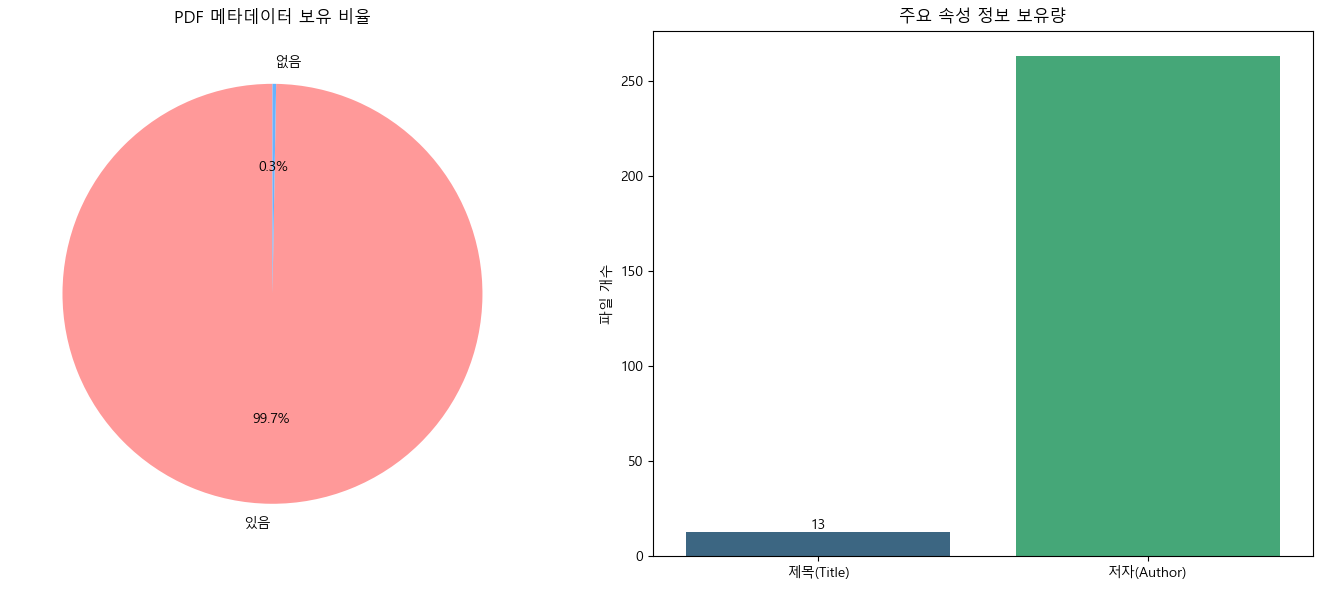

In [20]:
# ==========================================
# 1. 설정
# ==========================================
base_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\files_modified\원본데이터(공고명+사업명) 수정본_v2"

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 메타데이터 분석 로직
# ==========================================
def analyze_metadata():
    if not os.path.exists(base_path):
        print(f"경로를 찾을 수 없음: {base_path}")
        return

    print(f"[6단계: 메타데이터] 속성 정보(저자, 제목 등) 생존 여부 확인 중")
    
    meta_results = []
    
    # 체크할 주요 속성 키값들
    target_keys = ['/Title', '/Author', '/Subject', '/Producer', '/Creator']
    
    # 전체 파일 탐색
    total_files_count = sum([len(files) for r, d, files in os.walk(base_path) if any(f.endswith('.pdf') for f in files)])
    processed_count = 0

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith('.pdf'):
                processed_count += 1
                file_path = os.path.join(root, file)
                
                info = {
                    "file_name": file,
                    "has_metadata": False,  # 메타데이터 존재 여부
                    "title_exists": False,
                    "author_exists": False,
                    "raw_title": ""         # 실제 제목 내용 (확인용)
                }

                try:
                    reader = PdfReader(file_path)
                    meta = reader.metadata
                    
                    if meta:
                        info["has_metadata"] = True
                        
                        # 제목이 있는지, 그리고 비어있지 않은지 확인
                        if meta.get('/Title') and str(meta.get('/Title')).strip() != "":
                            info["title_exists"] = True
                            info["raw_title"] = str(meta.get('/Title'))
                            
                        # 저자가 있는지 확인
                        if meta.get('/Author') and str(meta.get('/Author')).strip() != "":
                            info["author_exists"] = True
                            
                except:
                    pass
                
                meta_results.append(info)

    df = pd.DataFrame(meta_results)

    if len(df) == 0:
        print("데이터가 없음")
        return

    # ==========================================
    # 3. 통계 요약
    # ==========================================
    print("\n" + "="*40)
    print("[메타데이터 분석 결과]")
    print("="*40)
    
    has_meta_count = df['has_metadata'].sum()
    has_title_count = df['title_exists'].sum()
    has_author_count = df['author_exists'].sum()
    
    print(f" - 총 파일 수: {len(df)}개")
    print(f" - 메타데이터 정보 있음: {has_meta_count}개 ({has_meta_count/len(df)*100:.1f}%)")
    print(f" - '제목(Title)' 속성 있음: {has_title_count}개 ({has_title_count/len(df)*100:.1f}%)")
    print(f" - '저자(Author)' 속성 있음: {has_author_count}개 ({has_author_count/len(df)*100:.1f}%)")
    
    print("\n[실제 메타데이터 제목 예시 Top 5]")
    # 제목이 있는 것들 중 5개만 뽑아서 보여줌 (쓰레기 값인지 진짜인지 확인용)
    examples = df[df['title_exists'] == True]['raw_title'].head(5)
    if len(examples) > 0:
        for ex in examples:
            print(f"{ex}")
    else:
        print("   (유효한 제목 정보가 하나도 없음)")

    # ==========================================
    # 4. 시각화
    # ==========================================
    print("\n시각화 그래프 생성 중")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 그래프 1: 메타데이터 유무 비율 (Pie Chart)
    labels = ['있음', '없음']
    sizes = [has_meta_count, len(df) - has_meta_count]
    colors = ['#ff9999','#66b3ff']
    
    axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    axes[0].set_title('PDF 메타데이터 보유 비율')
    
    # 그래프 2: 속성별 보유 현황 (Bar Chart)
    properties = ['제목(Title)', '저자(Author)']
    counts = [has_title_count, has_author_count]
    
    sns.barplot(x=properties, y=counts, palette='viridis', ax=axes[1])
    axes[1].set_title('주요 속성 정보 보유량')
    axes[1].set_ylabel('파일 개수')
    axes[1].bar_label(axes[1].containers[0]) # 막대 위에 숫자 표시

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_metadata()

- 분석
    - 우리는 앞에서 CSV의 정보를 최대한 정제를 해왔다 그리고 CSV를 네비게이션처럼 사용하려고 했었다
    - 이 결과는 우리가 PDF의 메타 데이터 정보는 사용을 못한다는걸 시사한다 제목과 같은 경우에는 그 수도 별로 없는데 단순히 사용을 못하는 수준이 아니라 이걸 사용하면 거의 노이즈 수준이 될 것이다
    - 앞으로의 실험은 CSV의 메타 데이터만을 사용해야 된다는 것을 더욱 증명해준다

# 원본 데이터 파싱(Upstage Document Parse 사용)

In [ ]:
import os
from langchain_upstage import UpstageDocumentParseLoader

# 1. API 키 설정
os.environ["UPSTAGE_API_KEY"] = "up_nvYnpB1FFJr2Z4buOmk06jvIp1mru"

# 2. 테스트할 파일 경로 (4쪽 모아찍기 파일만 남김)
file_path = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\final datas\Files\proj_002\20241002912-00_1728021605690_입찰공고문_2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선.pdf"

def test_full_page_content(path, target_page_index):
    print(f"▶ 파일 읽는 중: {os.path.basename(path)}")
    
    try:
        loader = UpstageDocumentParseLoader(
            path,
            output_format="markdown",
            coordinates=False,
            split="page"
        )
        
        # 전체 로드
        docs = loader.load()
        
        # 페이지 수 확인
        total_pages = len(docs)
        print(f"총 파싱된 페이지 수: {total_pages}페이지")

        # 요청한 페이지(3페이지 = index 2)가 있는지 확인
        if total_pages > target_page_index:
            target_doc = docs[target_page_index] # 0부터 시작하므로 2가 3페이지
            
            print(f"\n{'='*20} [Page {target_page_index + 1} 전문 출력] {'='*20}")
            print(target_doc.page_content) # 중략 없이 전체 출력
            print(f"{'='*50}\n")
            
        else:
            print(f"오류: 3페이지를 찾을 수 없음 (총 {total_pages}페이지)")

    except Exception as e:
        print(f"오류 발생: {e}")

# 실행 (3페이지 확인을 위해 index에 2를 넣음)
if os.path.exists(file_path):
    test_full_page_content(file_path, target_page_index=2)
else:
    print("파일 경로를 다시 확인해야됨")

▶ 파일 읽는 중: 20241002912-00_1728021605690_입찰공고문_2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선.pdf
총 파싱된 페이지 수: 4페이지

==================== [Page 3 전문 출력] ====================
- 라. 「국가를 당사자로 하는 계약에 관한 법률 시행규칙」 제44조 및 「(계약
- 예규) 용역입찰유의서」 제12조에 정한 입찰무효 해당여부 확인을 위하여
- 등록정보 확인을 위한 서류(법인등기부등본, 입찰대리인임을 확인할 수
- 있는 서류, 관련되는 면허 등을 증명하는 서류 등)를 요청하는 경우, 낙찰
- 대상자는 관계서류를 재단으로 제출하여야 함
 # 10. 계약조건 # ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­ - 가. 낙찰자는 낙찰 이후 10일 이내에 소정의 서식에 의한 계약서에 의하여
- 계약을 체결하여야 하며, 계약 체결 시 계약금액의 100분의 10이상
- (「국가계약법 시행령」 제50조 제1항 단서조항에 따른 기획재정부장관이
- 기간을 정하여 고시한 경우에는 100분의 5이상)의 계약보증금을 유가증권
- 또는 보증 보험증권으로 제출하여야 함
- 나. 기타 계약조건은 제안요청서, 제안서, 용역계약 일반조건과 관련 법령에 따름
 # 11. 불공정행위 금지 # ­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­ 가. 입찰자 또는 계약상대자는 입찰·낙찰, 계약체결 또는 계약이행 등의 과
정에서 입찰 및 계약의 공정한 질서를 저해하는 다음 각 호의 어느 하
나에 해당하는 행위를 하여서는 아니됨 - ① 금품·향응 등의 공여·약속 또는 공여의 의사를 표시하는 행위
- ② 입찰가격의 사전 협의 또는 특정인의 낙찰을 위한 담합 등 공정한 경쟁

In [ ]:
# 확인할 파일 경로
target_file = r"C:\AI Projects\codeit\코드잇 AI\프로젝트\중급 프로젝트\final datas\Files\proj_002\20241002912-00_1728021605690_입찰공고문_2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선.pdf"

def visualize_in_browser(file_path, page_index=2): # page_index 2 = 3페이지
    print(f"▶ 시각화 준비 중: {os.path.basename(file_path)}")
    
    # ---------------------------------------------------------
    # TEST 1: Markdown 렌더링 확인 (RAG에 실제 쓰일 데이터)
    # ---------------------------------------------------------
    print("   [1/2] Markdown 포맷 파싱 및 렌더링 중...")
    loader_md = UpstageDocumentParseLoader(
        file_path, output_format="markdown", coordinates=False, split="page"
    )
    docs_md = loader_md.load()
    
    if len(docs_md) > page_index:
        md_content = docs_md[page_index].page_content
        
        # Markdown을 보기 좋은 HTML로 변환 (표 지원 확장기능 사용)
        html_from_md = markdown.markdown(md_content, extensions=['tables', 'fenced_code'])
        
        # 스타일(CSS)을 입혀서 문서처럼 보이게 만듦
        final_html_md = f"""
        <html>
        <head>
            <title>Markdown 렌더링 결과 (Page {page_index+1})</title>
            <style>
                body {{ font-family: 'Malgun Gothic', sans-serif; max-width: 900px; margin: 40px auto; padding: 20px; line-height: 1.6; border: 1px solid #ddd; box-shadow: 0 0 10px rgba(0,0,0,0.1); }}
                h1, h2, h3 {{ color: #333; border-bottom: 2px solid #333; padding-bottom: 10px; }}
                table {{ border-collapse: collapse; width: 100%; margin: 20px 0; }}
                th, td {{ border: 1px solid #bbb; padding: 8px; text-align: left; }}
                th {{ background-color: #f2f2f2; font-weight: bold; }}
                code {{ background-color: #f9f9f9; padding: 2px 5px; border-radius: 3px; font-family: monospace; }}
                .tag {{ background-color: #007bff; color: white; padding: 5px 10px; display: inline-block; border-radius: 5px; margin-bottom: 20px; }}
            </style>
        </head>
        <body>
            <div class="tag">Markdown Mode (RAG용)</div>
            {html_from_md}
        </body>
        </html>
        """
        open_in_tab(final_html_md)
    else:
        print("   페이지 범위 초과로 Markdown 확인 불가")

    # ---------------------------------------------------------
    # TEST 2: HTML 포맷 확인 (Upstage 원본 HTML 구조)
    # ---------------------------------------------------------
    print("   [2/2] HTML 포맷 파싱 및 렌더링 중...")
    try:
        loader_html = UpstageDocumentParseLoader(
            file_path, output_format="html", coordinates=False, split="page"
        )
        docs_html = loader_html.load()
        
        if len(docs_html) > page_index:
            raw_html = docs_html[page_index].page_content
            
            final_html_raw = f"""
            <html>
            <head>
                <title>HTML 원본 구조 결과 (Page {page_index+1})</title>
                <style>
                    body {{ font-family: 'Malgun Gothic', sans-serif; max-width: 900px; margin: 40px auto; padding: 20px; border: 1px solid #ff9999; }}
                    .tag {{ background-color: #dc3545; color: white; padding: 5px 10px; display: inline-block; border-radius: 5px; margin-bottom: 20px; }}
                    /* Upstage HTML은 기본 스타일이 없으므로 가독성용 스타일 추가 */
                    table {{ border-collapse: collapse; width: 100%; border: 2px solid blue; }}
                    td, th {{ border: 1px solid blue; padding: 5px; }}
                </style>
            </head>
            <body>
                <div class="tag">HTML Mode (구조 확인용)</div>
                <hr>
                {raw_html}
            </body>
            </html>
            """
            open_in_tab(final_html_raw)
        
    except Exception as e:
        print(f"   HTML 모드 파싱 중 에러 (무시 가능): {e}")

def open_in_tab(html_string):
    # 시스템 임시 폴더에 잠시 파일을 만들었다가 브라우저로 열기
    # delete=False로 해야 브라우저가 파일을 읽을 수 있음 (읽고 나서 나중에 청소됨)
    with tempfile.NamedTemporaryFile('w', delete=False, suffix='.html', encoding='utf-8') as f:
        f.write(html_string)
        url = 'file://' + f.name
        webbrowser.open(url) # 기본 브라우저 새 탭으로 열기

# 실행
if os.path.exists(target_file):
    visualize_in_browser(target_file, page_index=2) # 3페이지 확인
else:
    print("파일 경로를 확인해야됨")

▶ 시각화 준비 중: 20241002912-00_1728021605690_입찰공고문_2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선.pdf
   [1/2] Markdown 포맷 파싱 및 렌더링 중...
   [2/2] HTML 포맷 파싱 및 렌더링 중...


### HTML 렌더링 시각화

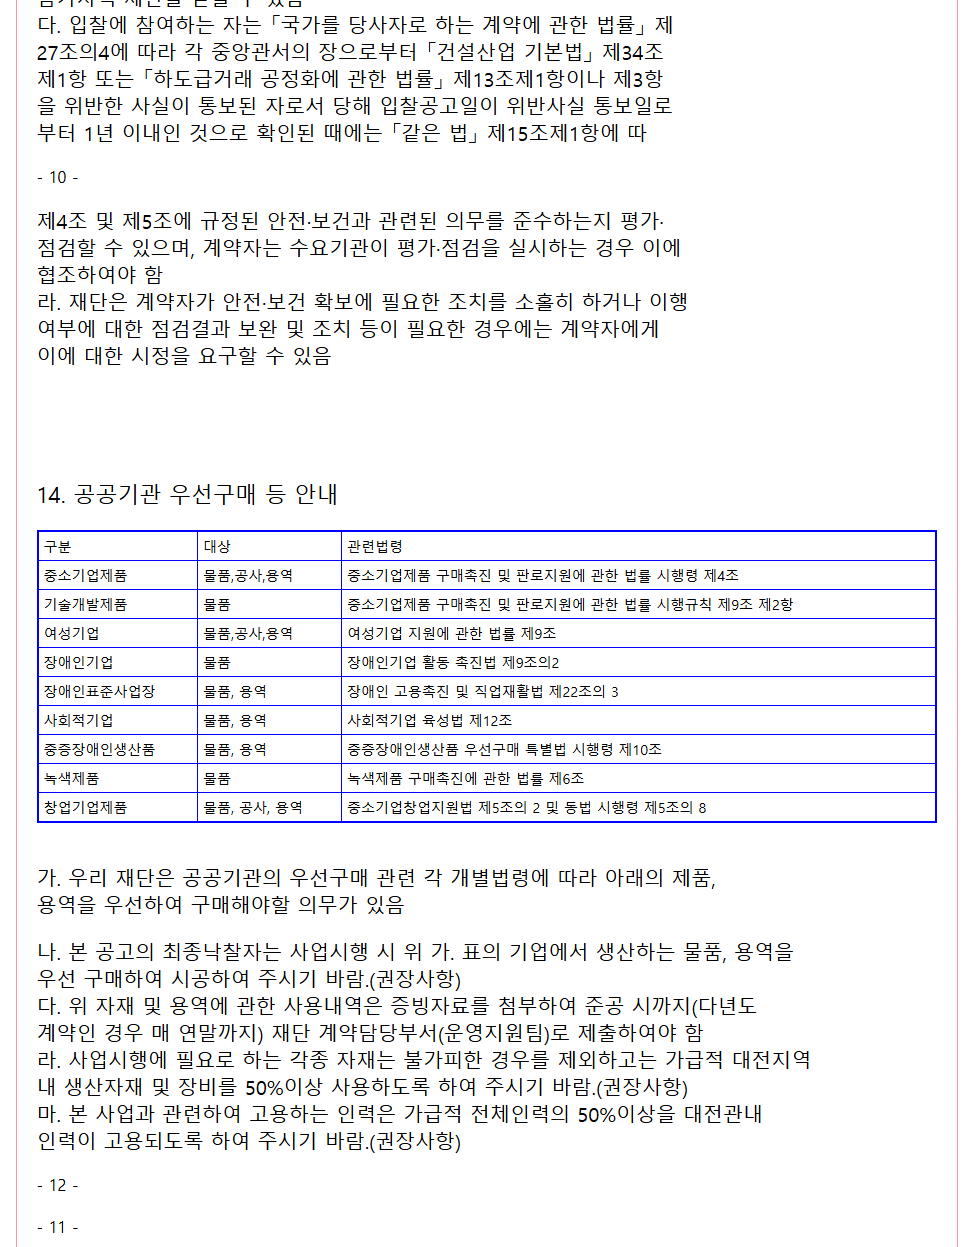

### Markdown 렌더링 시각화

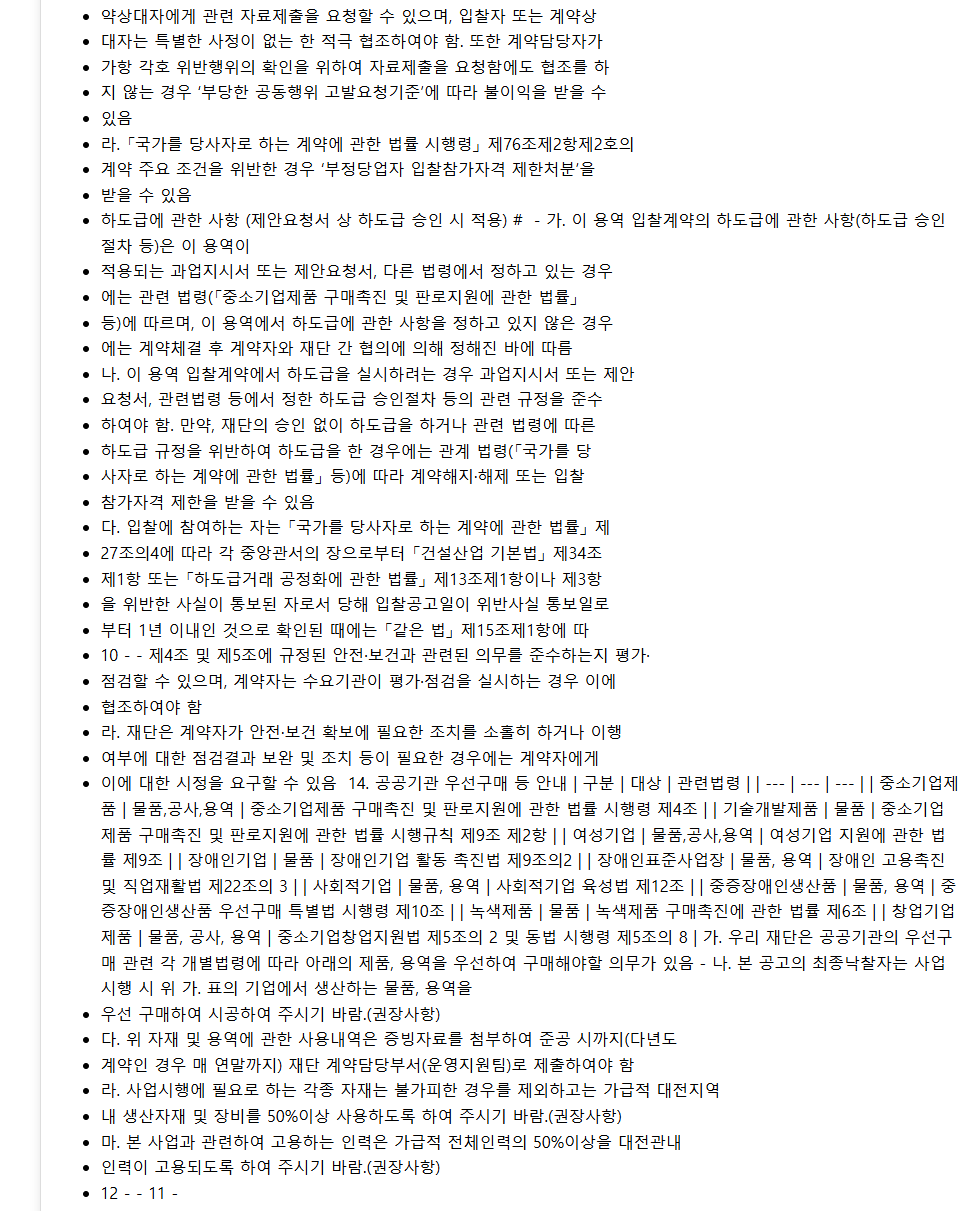

## 6팀 파서 Upstage로 최종 확정